# 4) Assembling the Model

In [1]:
# Loaded all the libraries because I'll be using a whole lot

# Core Libraries
import warnings
import os
import glob
import joblib

import numpy as np
import pandas as pd
from scipy.stats.mstats import winsorize

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.spatial.distance import cosine

warnings.filterwarnings("ignore")
from scipy.stats.mstats import winsorize

# Clean plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Optional display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Scikit-Learn: Model Selection / Validation
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)

# Scikit-Learn: Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Scikit-Learn: Regression Models
from sklearn.linear_model import LinearRegression

# Scikit-Learn: Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import Lasso

# Scikit-Learn: Ensemble Models
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
    BaggingClassifier,
)


from matplotlib.ticker import PercentFormatter

# Scikit-Learn: Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity

# Gradient Boosting Libraries
import xgboost as xgb
import lightgbm as lgb

# Interpretability
import shap

# Association Rules
from mlxtend.frequent_patterns import apriori, association_rules


print("✅ Libraries loaded!")

# Define random state
RANDOM_STATE = 51

✅ Libraries loaded!


In [2]:
# Import the main dataframe
df = pd.read_csv('df.csv')

df.head(10)

,Unnamed: 0,index,ticker,fiscal_year,fiscal_period,period_end_date,inc_currency,inc_revenue,inc_revenue_product,inc_revenue_services,inc_cost_of_revenue,inc_gross_profit,inc_operating_expenses,inc_research_development,inc_selling_general_administrative,inc_selling_marketing_expenses,inc_general_admin_expenses,inc_depreciation_amortization,inc_depreciation,inc_amortization_of_intangibles,inc_stock_based_compensation,inc_operating_income,inc_interest_expense,inc_interest_income,inc_other_income_expense,inc_income_before_taxes,inc_income_tax_expense,inc_net_income_continuing_operations,inc_net_income_discontinued_operations,inc_net_income,inc_basic_shares_outstanding,inc_diluted_shares_outstanding,inc_weighted_average_basic_shares,inc_weighted_average_diluted_shares,inc_basic_eps,inc_diluted_eps,inc_dividends_per_share,inc_comprehensive_income,inc_other_comprehensive_income,inc_impairment_charges,inc_restructuring_costs,inc_net_income_noncontrolling_interest,inc_preferred_dividends,inc_net_income_available_to_common,inc_revenue_from_contracts_excluding_tax,inc_revenue_from_contracts_including_tax,inc_income_before_taxes_and_extraordinary,inc_other_comprehensive_income_net_of_tax,inc_comprehensive_income_net_of_tax,inc_interest_income_operating,api_ticker_used,bal_currency,bal_total_assets,bal_current_assets,bal_non_current_assets,bal_cash_and_equivalents,bal_short_term_investments,bal_long_term_investments,bal_accounts_receivable,bal_inventory,bal_property_plant_equipment,bal_goodwill,bal_intangible_assets,bal_other_current_assets,bal_other_non_current_assets,bal_prepaid_expenses,bal_total_liabilities,bal_current_liabilities,bal_non_current_liabilities,bal_accounts_payable,bal_accruals_current,bal_short_term_debt,bal_deferred_revenue_current,bal_other_current_liabilities,bal_long_term_debt,bal_deferred_tax_liabilities,bal_deferred_revenue_non_current,bal_other_non_current_liabilities,bal_accrued_liabilities,bal_total_equity,bal_retained_earnings,bal_additional_paid_in_capital,bal_treasury_stock,bal_treasury_shares,bal_accumulated_other_comprehensive_income,bal_noncontrolling_interest,bal_preferred_stock_value,bal_operating_lease_right_of_use_assets,bal_operating_lease_liability_current,bal_operating_lease_liability_noncurrent,bal_investment_securities_fair_value,bal_available_for_sale_debt_securities,bal_common_stock_shares_authorized,bal_shares_issued,bal_common_stock_par_value_per_share,bal_total_debt,bal_net_debt,bal_working_capital,bal_tangible_book_value,bal_book_value_per_share,cf_currency,cf_net_cash_from_operations,cf_deferred_taxes,cf_change_in_receivables,cf_change_in_inventory,cf_change_in_accounts_payable,cf_change_in_deferred_revenue,cf_other_operating_assets_change,cf_other_operating_liabilities_change,cf_tax_withholding_payments,cf_other_misc_operating,cf_net_cash_from_investing,cf_capital_expenditures,cf_acquisitions,cf_purchase_of_investments,cf_proceeds_from_investments,cf_recurring_capital_expenditures,cf_net_cash_from_financing,cf_issuance_of_debt,cf_repayment_of_debt,cf_repurchase_of_stock,cf_cash_at_beginning_of_period,cf_cash_at_end_of_period,cf_net_change_in_cash,cf_free_cash_flow,cf_levered_free_cash_flow,shr_basic_shares_outstanding,shr_diluted_shares_outstanding,shr_weighted_average_basic_shares,shr_weighted_average_diluted_shares,shr_treasury_shares,shr_dilution_percentage,shr_is_buyback,profile_api_ticker_used,sector,industry,company_name,fiscal_year_end,website_url,exchange,buyback_quarter,inc_net_interest_income,inc_provision_for_credit_losses,inc_net_interest_margin,inc_return_on_average_assets,inc_return_on_average_equity,inc_fee_income,inc_trading_revenue,inc_interest_income_loans_commercial,inc_interest_income_loans_consumer,inc_interest_income_loans_total,inc_interest_income_securities,inc_interest_expense_deposits,inc_interest_expense_borrowings,inc_interest_expense_long_term_debt,inc_net_interest_income_after_provision,inc_investment_banking_revenue,inc_asset_management_fees,inc_service_charg

## Train / Validation / Test

In [3]:
X = df.drop(columns=['buyback_next_quarter']) # remove predictor        # should I do a time based split? => NO
y = df['buyback_next_quarter']

# Train / validation / test split (60% / 20% / 20%)
#  we split further into validation + test for proper evaluation
# stratify=y preserves the positive rate in all splits                  
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]:,} records  ({y_train.mean():.1%} positive)")
print(f"Validation set: {X_val.shape[0]:,} records  ({y_val.mean():.1%} positive)")
print(f"Test set:       {X_test.shape[0]:,} records  ({y_test.mean():.1%} positive)")

Training set:   10,391 records  (42.6% positive)
Validation set: 3,464 records  (42.6% positive)
Test set:       3,464 records  (42.6% positive)


## EDA post Split on Train Set

,Unnamed: 0,index,ticker,fiscal_year,fiscal_period,period_end_date,inc_currency,inc_revenue,inc_revenue_product,inc_revenue_services,inc_cost_of_revenue,inc_gross_profit,inc_operating_expenses,inc_research_development,inc_selling_general_administrative,inc_selling_marketing_expenses,inc_general_admin_expenses,inc_depreciation_amortization,inc_depreciation,inc_amortization_of_intangibles,inc_stock_based_compensation,inc_operating_income,inc_interest_expense,inc_interest_income,inc_other_income_expense,inc_income_before_taxes,inc_income_tax_expense,inc_net_income_continuing_operations,inc_net_income_discontinued_operations,inc_net_income,inc_basic_shares_outstanding,inc_diluted_shares_outstanding,inc_weighted_average_basic_shares,inc_weighted_average_diluted_shares,inc_basic_eps,inc_diluted_eps,inc_dividends_per_share,inc_comprehensive_income,inc_other_comprehensive_income,inc_impairment_charges,inc_restructuring_costs,inc_net_income_noncontrolling_interest,inc_preferred_dividends,inc_net_income_available_to_common,inc_revenue_from_contracts_excluding_tax,inc_revenue_from_contracts_including_tax,inc_income_before_taxes_and_extraordinary,inc_other_comprehensive_income_net_of_tax,inc_comprehensive_income_net_of_tax,inc_interest_income_operating,api_ticker_used,bal_currency,bal_total_assets,bal_current_assets,bal_non_current_assets,bal_cash_and_equivalents,bal_short_term_investments,bal_long_term_investments,bal_accounts_receivable,bal_inventory,bal_property_plant_equipment,bal_goodwill,bal_intangible_assets,bal_other_current_assets,bal_other_non_current_assets,bal_prepaid_expenses,bal_total_liabilities,bal_current_liabilities,bal_non_current_liabilities,bal_accounts_payable,bal_accruals_current,bal_short_term_debt,bal_deferred_revenue_current,bal_other_current_liabilities,bal_long_term_debt,bal_deferred_tax_liabilities,bal_deferred_revenue_non_current,bal_other_non_current_liabilities,bal_accrued_liabilities,bal_total_equity,bal_retained_earnings,bal_additional_paid_in_capital,bal_treasury_stock,bal_treasury_shares,bal_accumulated_other_comprehensive_income,bal_noncontrolling_interest,bal_preferred_stock_value,bal_operating_lease_right_of_use_assets,bal_operating_lease_liability_current,bal_operating_lease_liability_noncurrent,bal_investment_securities_fair_value,bal_available_for_sale_debt_securities,bal_common_stock_shares_authorized,bal_shares_issued,bal_common_stock_par_value_per_share,bal_total_debt,bal_net_debt,bal_working_capital,bal_tangible_book_value,bal_book_value_per_share,cf_currency,cf_net_cash_from_operations,cf_deferred_taxes,cf_change_in_receivables,cf_change_in_inventory,cf_change_in_accounts_payable,cf_change_in_deferred_revenue,cf_other_operating_assets_change,cf_other_operating_liabilities_change,cf_tax_withholding_payments,cf_other_misc_operating,cf_net_cash_from_investing,cf_capital_expenditures,cf_acquisitions,cf_purchase_of_investments,cf_proceeds_from_investments,cf_recurring_capital_expenditures,cf_net_cash_from_financing,cf_issuance_of_debt,cf_repayment_of_debt,cf_repurchase_of_stock,cf_cash_at_beginning_of_period,cf_cash_at_end_of_period,cf_net_change_in_cash,cf_free_cash_flow,cf_levered_free_cash_flow,shr_basic_shares_outstanding,shr_diluted_shares_outstanding,shr_weighted_average_basic_shares,shr_weighted_average_diluted_shares,shr_treasury_shares,shr_dilution_percentage,shr_is_buyback,profile_api_ticker_used,sector,industry,company_name,fiscal_year_end,website_url,exchange,buyback_quarter,inc_net_interest_income,inc_provision_for_credit_losses,inc_net_interest_margin,inc_return_on_average_assets,inc_return_on_average_equity,inc_fee_income,inc_trading_revenue,inc_interest_income_loans_commercial,inc_interest_income_loans_consumer,inc_interest_income_loans_total,inc_interest_income_securities,inc_interest_expense_deposits,inc_interest_expense_borrowings,inc_interest_expense_long_term_debt,inc_net_interest_income_after_provision,inc_investment_banking_revenue,inc_asset_management_fees,inc_service_charg

<class 'pandas.core.frame.DataFrame'>
Index: 10391 entries, 4915 to 3018
Columns: 767 entries, Unnamed: 0 to accumulated_depletion_ratio_q
dtypes: float64(747), int64(4), object(16)
memory usage: 60.9+ MB


bal_investment_properties_fair_value     100.0
inc_vegetation_management_costs          100.0
inc_reserve_replacement_ratio            100.0
inc_finding_development_costs_per_boe    100.0
inc_reserve_life_years                   100.0
                                         ...  
nonperforming_assets_ratio_q               0.0
cet1_ratio_q                               0.0
tier1_capital_ratio_q                      0.0
risk_weighted_assets_to_assets_q           0.0
accumulated_depletion_ratio_q              0.0
Length: 767, dtype: float64

Rows with missing value: 10391


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,10391.0,8.671932e+03,5.021312e+03,0.000000e+00,4338.5,8.684000e+03,1.303200e+04,1.731800e+04
index,10391.0,8.671932e+03,5.021312e+03,0.000000e+00,4338.5,8.684000e+03,1.303200e+04,1.731800e+04
fiscal_year,10391.0,2.022958e+03,1.373808e+00,2.021000e+03,2022.0,2.023000e+03,2.024000e+03,2.025000e+03
inc_revenue,10228.0,4.985517e+09,1.252799e+10,-3.791000e+09,540484250.0,1.539850e+09,4.082000e+09,1.801690e+11
inc_revenue_product,4225.0,4.115834e+09,1.094132e+10,-2.840000e+08,212892000.0,1.019200e+09,3.715600e+09,1.680030e+11
...,...,...,...,...,...,...,...,...
proved_developed_properties_to_assets_q,10391.0,2.132610e-03,8.571875e-02,0.000000e+00,0.0,0.000000e+00,0.000000e+00,4.524141e+00
proved_undeveloped_properties_to_assets_q,10391.0,1.872241e-04,6.956526e-03,0.000000e+00,0.0,0.000000e+00,0.000000e+00,3.648365e-01
unproved_properties_to_assets_q,10391.0,2.101751e-05,1.973279e-03,0.000000e+00,0.0,0.000000e+00,0.000000e+00,2.003385e-01
refining_assets_intensity_q,10391.0,5.098647e-04,1.961325e-02,0.000000e+00,0.0,0.000000e+00,0.000000e+00,8.835379e-01


16

751

['ticker',
 'fiscal_period',
 'period_end_date',
 'inc_currency',
 'api_ticker_used',
 'bal_currency',
 'cf_currency',
 'shr_is_buyback',
 'profile_api_ticker_used',
 'sector']

ticker
A       19
NDSN    19
MSTR    19
MTB     19
MTCH    19
MTD     19
MTN     19
MTSI    19
MU      19
MUSA    19
NBIX    19
NCLH    19
NDAQ    19
NEE     19
MSGS    19
Name: count, dtype: int64

np.int64(0)

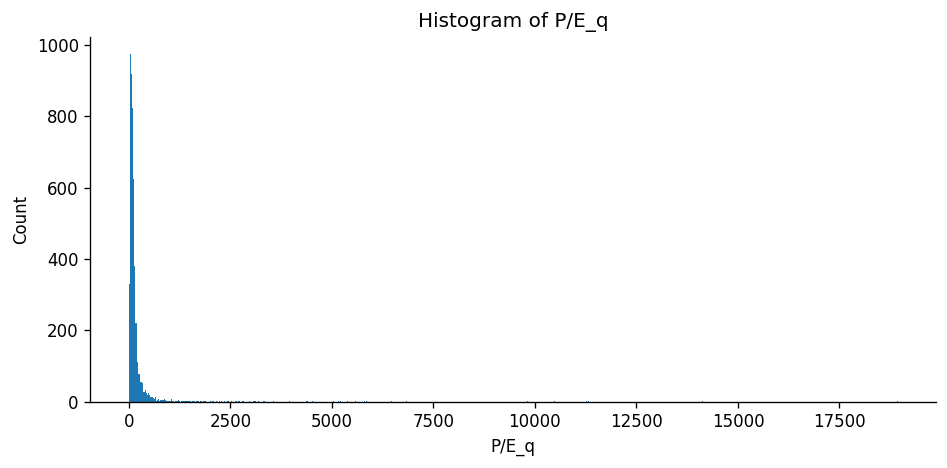

In [4]:
# EDA for Train Set

display(X_train.sample(100))

X_train.info()

# Missing value percentage per column
missing_pct = (X_train.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct)

# Amount of rows with any missing values
rows_with_any_missing = X_train.isna().any(axis=1).sum()
print(f"Rows with missing value: {rows_with_any_missing}")

# Summary for numeric columns
display(X_train.describe().T)

# Identify categorical columns quickly
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

display(len(cat_cols), len(num_cols), cat_cols[:10])

# frequency table for a categorical column
# If the dataset has no object columns, this cell will just show a message
if len(cat_cols) == 0:
    print("No categorical columns detected as object/category.")
else:
    col = cat_cols[0]
    display(df[col].value_counts(dropna=False).head(15))
    
# Count duplicate rows
dup_count = X_train.duplicated().sum()
display(dup_count)

# Histogram for a numeric column (SalePrice if present)
plt.figure(figsize=(8, 4))
col = "P/E_q" if "P/E_q" in X_train.columns else X_train.columns[0]
plt.hist(X_train[col].dropna(), bins=1000)
plt.title(f"Histogram of {col}")
plt.xlabel(col)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
X_train.head(100)

,Unnamed: 0,index,ticker,fiscal_year,fiscal_period,period_end_date,inc_currency,inc_revenue,inc_revenue_product,inc_revenue_services,inc_cost_of_revenue,inc_gross_profit,inc_operating_expenses,inc_research_development,inc_selling_general_administrative,inc_selling_marketing_expenses,inc_general_admin_expenses,inc_depreciation_amortization,inc_depreciation,inc_amortization_of_intangibles,inc_stock_based_compensation,inc_operating_income,inc_interest_expense,inc_interest_income,inc_other_income_expense,inc_income_before_taxes,inc_income_tax_expense,inc_net_income_continuing_operations,inc_net_income_discontinued_operations,inc_net_income,inc_basic_shares_outstanding,inc_diluted_shares_outstanding,inc_weighted_average_basic_shares,inc_weighted_average_diluted_shares,inc_basic_eps,inc_diluted_eps,inc_dividends_per_share,inc_comprehensive_income,inc_other_comprehensive_income,inc_impairment_charges,inc_restructuring_costs,inc_net_income_noncontrolling_interest,inc_preferred_dividends,inc_net_income_available_to_common,inc_revenue_from_contracts_excluding_tax,inc_revenue_from_contracts_including_tax,inc_income_before_taxes_and_extraordinary,inc_other_comprehensive_income_net_of_tax,inc_comprehensive_income_net_of_tax,inc_interest_income_operating,api_ticker_used,bal_currency,bal_total_assets,bal_current_assets,bal_non_current_assets,bal_cash_and_equivalents,bal_short_term_investments,bal_long_term_investments,bal_accounts_receivable,bal_inventory,bal_property_plant_equipment,bal_goodwill,bal_intangible_assets,bal_other_current_assets,bal_other_non_current_assets,bal_prepaid_expenses,bal_total_liabilities,bal_current_liabilities,bal_non_current_liabilities,bal_accounts_payable,bal_accruals_current,bal_short_term_debt,bal_deferred_revenue_current,bal_other_current_liabilities,bal_long_term_debt,bal_deferred_tax_liabilities,bal_deferred_revenue_non_current,bal_other_non_current_liabilities,bal_accrued_liabilities,bal_total_equity,bal_retained_earnings,bal_additional_paid_in_capital,bal_treasury_stock,bal_treasury_shares,bal_accumulated_other_comprehensive_income,bal_noncontrolling_interest,bal_preferred_stock_value,bal_operating_lease_right_of_use_assets,bal_operating_lease_liability_current,bal_operating_lease_liability_noncurrent,bal_investment_securities_fair_value,bal_available_for_sale_debt_securities,bal_common_stock_shares_authorized,bal_shares_issued,bal_common_stock_par_value_per_share,bal_total_debt,bal_net_debt,bal_working_capital,bal_tangible_book_value,bal_book_value_per_share,cf_currency,cf_net_cash_from_operations,cf_deferred_taxes,cf_change_in_receivables,cf_change_in_inventory,cf_change_in_accounts_payable,cf_change_in_deferred_revenue,cf_other_operating_assets_change,cf_other_operating_liabilities_change,cf_tax_withholding_payments,cf_other_misc_operating,cf_net_cash_from_investing,cf_capital_expenditures,cf_acquisitions,cf_purchase_of_investments,cf_proceeds_from_investments,cf_recurring_capital_expenditures,cf_net_cash_from_financing,cf_issuance_of_debt,cf_repayment_of_debt,cf_repurchase_of_stock,cf_cash_at_beginning_of_period,cf_cash_at_end_of_period,cf_net_change_in_cash,cf_free_cash_flow,cf_levered_free_cash_flow,shr_basic_shares_outstanding,shr_diluted_shares_outstanding,shr_weighted_average_basic_shares,shr_weighted_average_diluted_shares,shr_treasury_shares,shr_dilution_percentage,shr_is_buyback,profile_api_ticker_used,sector,industry,company_name,fiscal_year_end,website_url,exchange,buyback_quarter,inc_net_interest_income,inc_provision_for_credit_losses,inc_net_interest_margin,inc_return_on_average_assets,inc_return_on_average_equity,inc_fee_income,inc_trading_revenue,inc_interest_income_loans_commercial,inc_interest_income_loans_consumer,inc_interest_income_loans_total,inc_interest_income_securities,inc_interest_expense_deposits,inc_interest_expense_borrowings,inc_interest_expense_long_term_debt,inc_net_interest_income_after_provision,inc_investment_banking_revenue,inc_asset_management_fees,inc_service_charg

In [6]:
# I'm making a function to apply all the cleanup of the dataset I learn off the training data to train/validation/test because
# it confuses me doing it the manual way ngl

def shared_cleanup(X_train, X_val, X_test, missingness_percentage = 0.70):
    
    # Make the new datsasets
    X_train_base = X_train.copy()
    X_val_base = X_val.copy()
    X_test_base = X_test.copy()
    
    # Save the original column order so the left-right split still works
    original_columns = X_train.columns.tolist()
    
    # Now we have to split the dataframes into left and right because it gets too confusing if we don't
            
    # Split the df into pre-sector and post-sector specific feature engineering
    left_cols_all = original_columns[:original_columns.index('prepaid_expenses_to_assets_q') + 1]   # Sector agnostic ratios
    right_cols_all = original_columns[original_columns.index('fuel_cost_ratio_q'):]                  # Sector specific ratios
    
    # We must learn the cleanup rules from TRAIN ONLY
    
    # Drop columns that are truly all missing in train
    train_all_missing_cols = X_train_base.columns[X_train_base.isna().all()].tolist()
    
    # Drop columns with only one unique value in train
    train_constant_cols = [
        c for c in X_train_base.columns
        if X_train_base[c].nunique(dropna=False) <= 1
    ]
    
    # Drop columns where all rows equal 0 in train
    train_all_zero_cols = []
    for col in X_train_base.select_dtypes(include='number').columns:
        if (X_train_base[col] == 0).all():
            train_all_zero_cols.append(col)
    
    # Combine the base drop columns
    base_drop_cols = sorted(set(
        train_all_missing_cols + train_constant_cols + train_all_zero_cols
    ))
    
    # Apply the same base drops to train, validation, test
    X_train_base = X_train_base.drop(columns=base_drop_cols)
    X_val_base = X_val_base.drop(columns=base_drop_cols, errors='ignore')
    X_test_base = X_test_base.drop(columns=base_drop_cols, errors='ignore')
    
    # Make validation and test match train columns exactly
    X_val_base = X_val_base.reindex(columns=X_train_base.columns)
    X_test_base = X_test_base.reindex(columns=X_train_base.columns)
    
    
    # Split train
    left_cols = [col for col in left_cols_all if col in X_train_base.columns]
    right_cols = [col for col in right_cols_all if col in X_train_base.columns]
    
    X_train_base_left = X_train_base[left_cols]
    X_train_base_right = X_train_base[right_cols]
        
    # Split validation
    X_val_base_left = X_val_base[left_cols]
    X_val_base_right = X_val_base[right_cols]
        
    # Split test
    X_test_base_left = X_test_base[left_cols]
    X_test_base_right = X_test_base[right_cols]

    # We have too many features. Let's start deleting some.
    
    # ########################
    # df_left cleanup
    # ########################

    # Compute missingness in columns for left (main reason we are doing the left-right split)
    left_missingness_pct = X_train_base_left.isna().mean()
    left_high_missingness_cols = left_missingness_pct[left_missingness_pct > missingness_percentage].index.tolist()
    
    # Apply the same left drops to train, validation, test
    X_train_base_left = X_train_base_left.drop(columns=left_high_missingness_cols)
    X_val_base_left = X_val_base_left.drop(columns=left_high_missingness_cols, errors='ignore')
    X_test_base_left = X_test_base_left.drop(columns=left_high_missingness_cols, errors='ignore')


    # ########################
    # df_right cleanup
    # ########################
    
    # For the right side, the all missing / constant stuff was already handled above using train only
    # So we leave it alone here
    
    
    # ########################
    # combine left and right
    # ########################
    
    X_train_clean = pd.concat([X_train_base_left, X_train_base_right], axis=1)
    X_val_clean = pd.concat([X_val_base_left, X_val_base_right], axis=1)
    X_test_clean = pd.concat([X_test_base_left, X_test_base_right], axis=1)
    
    # Final check to make sure validation and test match training exactly
    X_val_clean = X_val_clean.reindex(columns=X_train_clean.columns)
    X_test_clean = X_test_clean.reindex(columns=X_train_clean.columns)
    
    
    # Let's Winsorize because we have some crazy, irrational financial ratios and multiples we know that can skew the machine learning models.
    winsorize_columns = X_train_clean.loc[:, 'accrual_ratio_q':].columns.tolist()
    
    for col in winsorize_columns:
        
        # Ignore error if the column is somehow not found
        if col not in X_train_clean.columns:
            continue
        
        # Only do this for numeric columns
        if not pd.api.types.is_numeric_dtype(X_train_clean[col]):
            continue
        
        # Drop NaNs before winsorizing because scipy can get weird with missing values
        train_non_missing = X_train_clean[col].dropna()
        
        # Skip if the column is completely missing after dropping NaNs
        if len(train_non_missing) == 0:
            continue
        
        # Learn the winsorization from train only (***important***)
        train_winsorized = winsorize(train_non_missing, limits=[0.01, 0.01])
        
        # Turn it back into a pandas Series so the index still matches
        train_winsorized = pd.Series(train_winsorized, index=train_non_missing.index)
        
        # Put the winsorized training values back
        X_train_clean.loc[train_non_missing.index, col] = train_winsorized
        
        # Get the implied lower and upper caps from the winsorized train column
        lower_cap = train_winsorized.min()
        upper_cap = train_winsorized.max()
        
        # Apply those same train-learned caps to validation
        if col in X_val_clean.columns:
            val_non_missing = X_val_clean[col].notna()
            X_val_clean.loc[val_non_missing, col] = X_val_clean.loc[val_non_missing, col].clip(lower=lower_cap, upper=upper_cap)
        
        # Apply those same train-learned caps to test
        if col in X_test_clean.columns:
            test_non_missing = X_test_clean[col].notna()
            X_test_clean.loc[test_non_missing, col] = X_test_clean.loc[test_non_missing, col].clip(lower=lower_cap, upper=upper_cap)
            
    # Drop junk index columns from train, validation, and test and also ticker!             {FIXED}
    cols_to_drop = ['Unnamed: 0', 'index', 'ticker', 'api_ticker_used', 'profile_api_ticker_used', 'company_name', 'price_ticker_yf',
                    'price_date','shr_is_buyback','exchange','share_growth_qoq']

    X_train_clean = X_train_clean.drop(columns=cols_to_drop, errors='ignore')
    X_val_clean = X_val_clean.drop(columns=cols_to_drop, errors='ignore')
    X_test_clean = X_test_clean.drop(columns=cols_to_drop, errors='ignore')
    
    # period_end_date has month day and year, so let's extract the month name then drop the original column
    for df in [X_train_clean, X_val_clean, X_test_clean]:
        if 'period_end_date' in df.columns:
            period_dates = pd.to_datetime(df['period_end_date'], errors='coerce')
            fiscal_month = period_dates.dt.month_name()
            
            df.drop(columns=['period_end_date'], inplace=True)
            
            # Make month the 3rd column
            df.insert(2, 'fiscal_month', fiscal_month)
    
    
    return X_train_clean, X_val_clean, X_test_clean


X_train_shared, X_val_shared, X_test_shared = shared_cleanup(X_train, X_val, X_test, missingness_percentage=0.30)

In [7]:
rows_before_cleaning = len(X_train.columns)
rows_after_cleaning = len(X_train_shared.columns)

print(f"There are {rows_before_cleaning} rows before cleaning and {rows_after_cleaning} rows after cleaning.")

print(f"Training set:   {X_train_shared.shape[0]:,} records  ({y_train.mean():.1%} positive)")
print(f"Validation set: {X_val_shared.shape[0]:,} records  ({y_val.mean():.1%} positive)")
print(f"Test set:       {X_test_shared.shape[0]:,} records  ({y_test.mean():.1%} positive)")

There are 767 rows before cleaning and 372 rows after cleaning.
Training set:   10,391 records  (42.6% positive)
Validation set: 3,464 records  (42.6% positive)
Test set:       3,464 records  (42.6% positive)


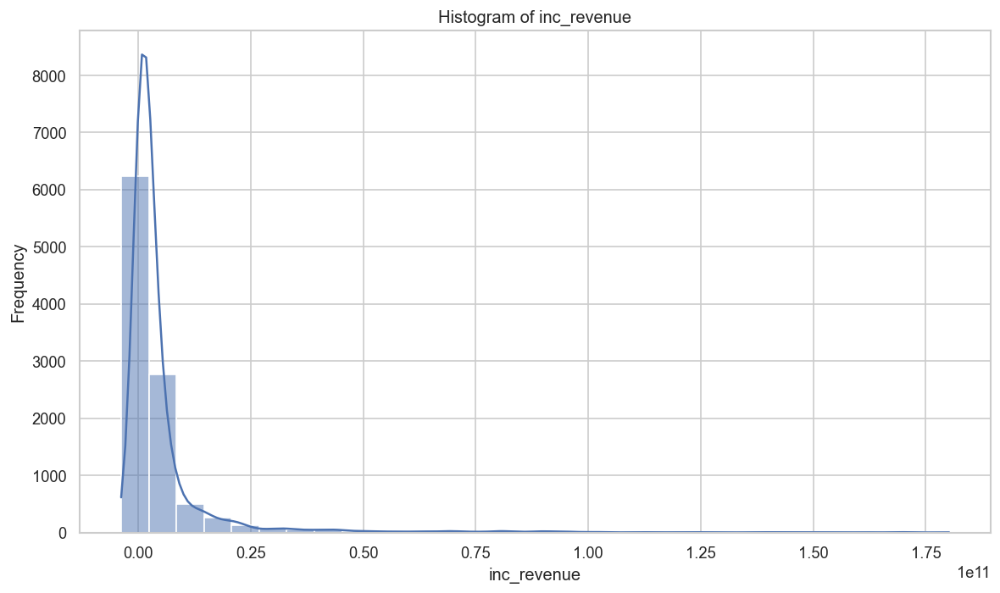

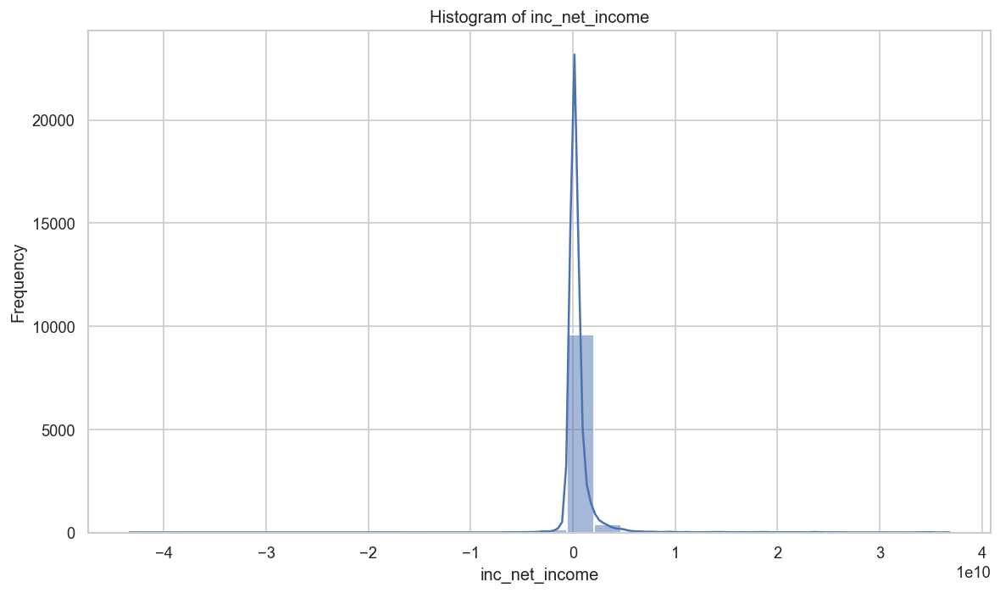

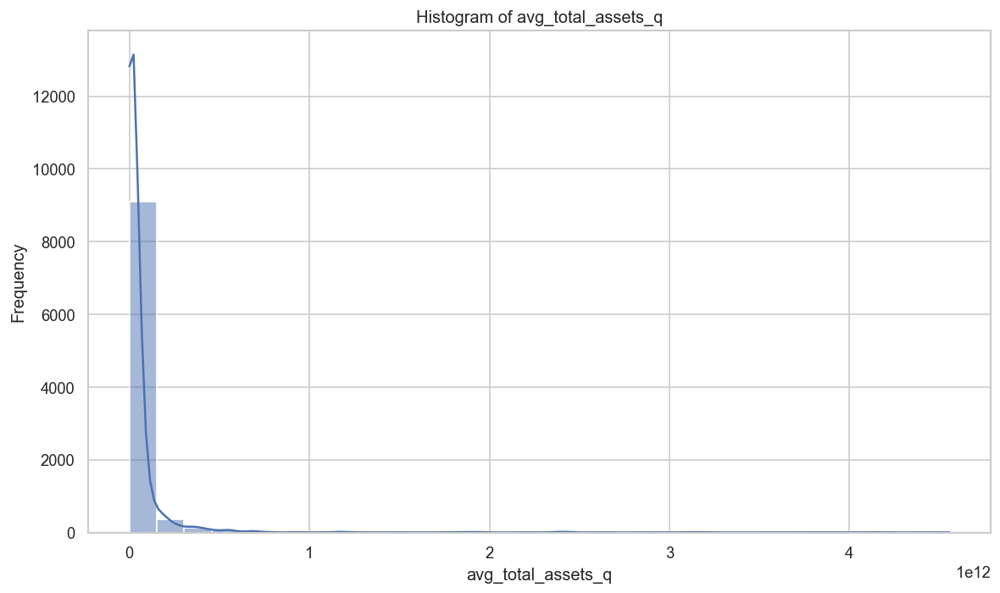

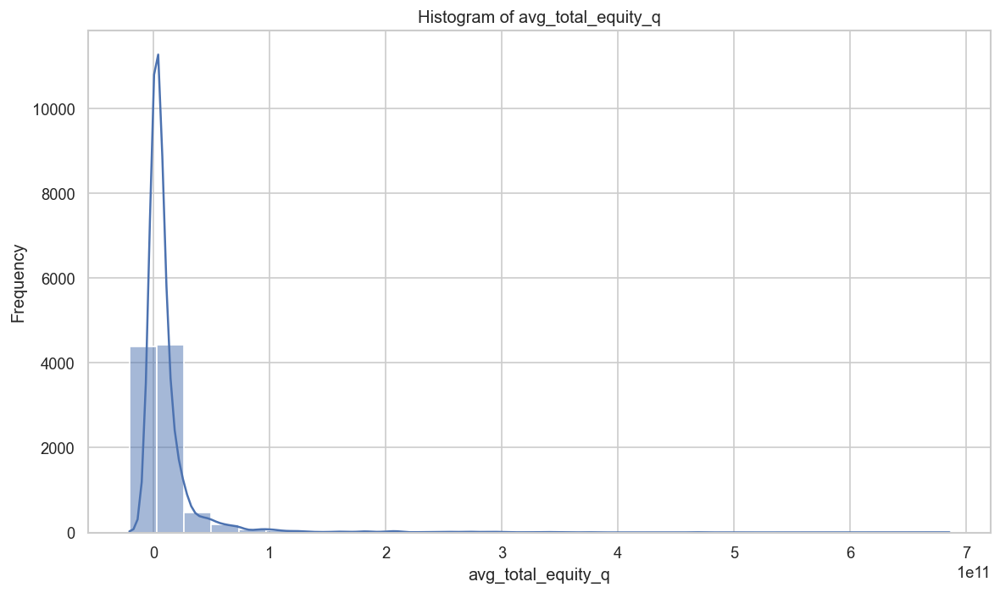

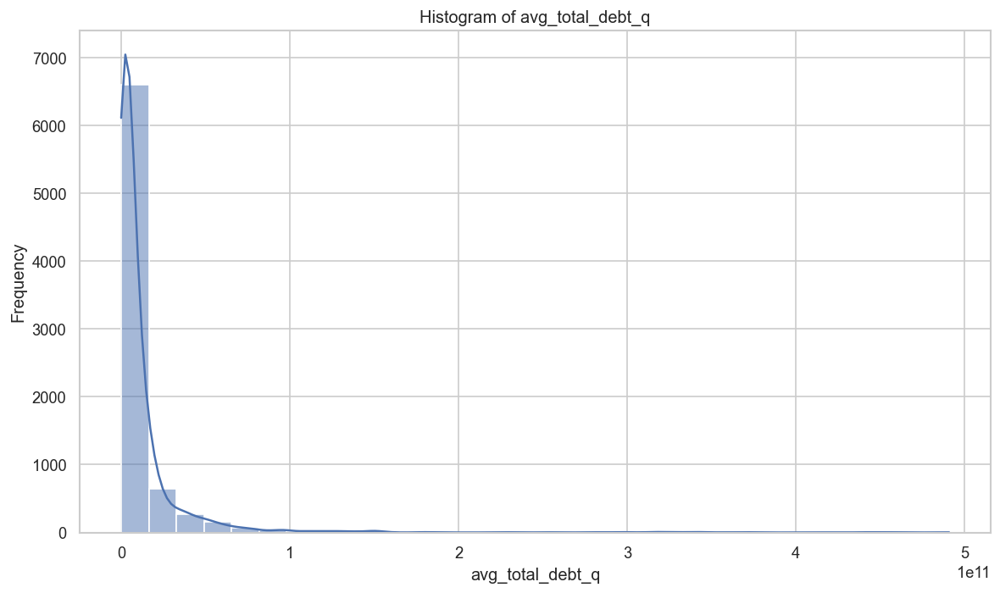

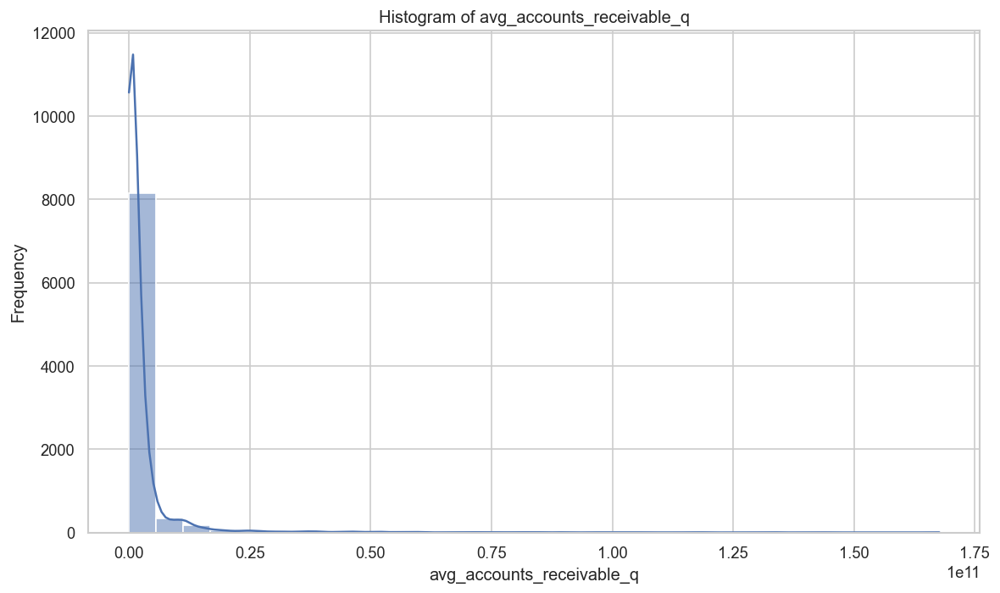

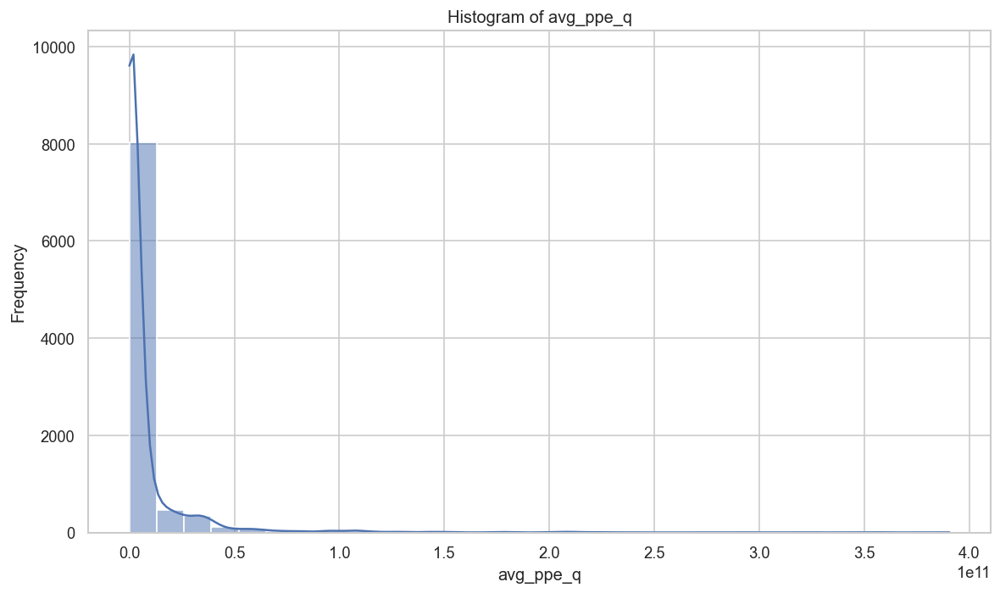

In [8]:
# Let's take a look at which key features to log (due to skewness and distribution)

# Select only a smaller set of important continuous variables
key_vars = [
    "inc_revenue",
    "inc_net_income",
    "cf_operating_net_cash_flow",
    "total_assets",
    "total_equity",
    "total_liabilities",
    "total_debt",
    "market_cap",
    "avg_total_assets_q",
    "avg_total_equity_q",
    "avg_total_debt_q",
    "avg_inventory_q",
    "avg_accounts_receivable_q",
    "avg_ppe_q"
]

# Keep only columns that actually exist in X_train_shared
key_vars = [col for col in key_vars if col in X_train_shared.columns]

hist_data = X_train_shared[key_vars]

# Set seaborn style
sns.set_theme(style="whitegrid")

# Create one histogram per selected column
for col in hist_data.columns:
    plt.figure(figsize=(10, 6))
    
    sns.histplot(
        data=hist_data,
        x=col,
        bins=30,
        kde=True
    )
    
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [9]:
# ── Helper: evaluation function ───────────────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_ev, y_ev, scaled=False, **fit_params): # Had to modify function to add fit_params, ChatGPT suggested to use ** (**kwargs)
    """Fit, predict, and print a clean evaluation summary."""
    model.fit(X_tr, y_tr, **fit_params)
    preds = model.predict(X_ev)
    probs = model.predict_proba(X_ev)[:, 1]

    cm = confusion_matrix(y_ev, preds)
    auc = roc_auc_score(y_ev, probs)
    acc = (preds == y_ev).mean()
    f1 = f1_score(y_ev, preds)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)   # recall for positive class
    specificity = tn / (tn + fp)


    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  AUC-ROC:     {auc:.4f}")
    print(f"  Sensitivity: {sensitivity:.4f}  (correctly identified buybacks)")
    print(f"  Specificity: {specificity:.4f}  (correctly identified non-buybacks)")
    print(f"  F-1 Score:   {f1:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"             Predicted 0   Predicted 1")
    print(f"  Actual 0:     {tn:5d}         {fp:5d}")
    print(f"  Actual 1:     {fn:5d}         {tp:5d}")
    print()
    return {'name': name, 'model': model, 'auc': auc, 'accuracy': acc,
            'sensitivity': sensitivity, 'specificity': specificity,'f1_score': f1
}


## Building the Logistic Regression and KNN Set

In [10]:
# Impute for left hand side

def sector_specific_impute_shared(X_train_shared, X_val_shared, X_test_shared, sector_col="sector"):
    
    X_train_imp = X_train_shared.copy()
    X_val_imp = X_val_shared.copy()
    X_test_imp = X_test_shared.copy()
    
    # Impute numeric columns only
    numeric_cols = X_train_imp.select_dtypes(include=["number"]).columns.tolist()
    
    # Overall training medians
    overall_train_medians = X_train_imp[numeric_cols].median()
    
    # Sector-specific training medians
    sector_train_medians = X_train_imp.groupby(sector_col)[numeric_cols].median()
    
    # Impute train
    for col in numeric_cols:
        train_sector_fill = X_train_imp[sector_col].map(sector_train_medians[col])
        X_train_imp[col] = X_train_imp[col].fillna(train_sector_fill)
        X_train_imp[col] = X_train_imp[col].fillna(overall_train_medians[col]) # I had trouble because some sectors are NaNs, so impute with non-sector median if sector is missing
    
    # Impute validation
    for col in numeric_cols:
        val_sector_fill = X_val_imp[sector_col].map(sector_train_medians[col])
        X_val_imp[col] = X_val_imp[col].fillna(val_sector_fill)
        X_val_imp[col] = X_val_imp[col].fillna(overall_train_medians[col]) # I had trouble because some sectors are NaNs, so impute with non-sector median if sector is missing
    
    # Impute test
    for col in numeric_cols:
        test_sector_fill = X_test_imp[sector_col].map(sector_train_medians[col])
        X_test_imp[col] = X_test_imp[col].fillna(test_sector_fill)
        X_test_imp[col] = X_test_imp[col].fillna(overall_train_medians[col]) # I had trouble because some sectors are NaNs, so impute with non-sector median if sector is missing
        
    # Apply log to certain skewed features:
    
    log_cols = [
        "inc_revenue",
        "basic_market_cap_q",
        "bal_total_assets",
        "bal_total_liabilities",
        "bal_total_debt",
        "avg_total_assets_q",
        "avg_total_liabilities_q",
        "avg_total_debt_q",
        "avg_ppe_q",
        "basic_market_cap_q",
        "diluted_market_cap_q"
    ]
    
   # Keep only columns that exist and are safe to log (negative)
    safe_log_cols = [
        col for col in log_cols
        if col in X_train_shared.columns and X_train_shared[col].min() >= 0
        ]
    
    # Apply log1p to train, validation, and test (log + 1 is industry standard to not blow up everything)
    for col in safe_log_cols:
        X_train_imp[col] = np.log1p(X_train_imp[col])
        X_val_imp[col] = np.log1p(X_val_imp[col])
        X_test_imp[col] = np.log1p(X_test_imp[col])
    
    # Dummy variables for sector and Q column:
    categorical_cols = X_train_imp.select_dtypes(include=['object', 'category']).columns.tolist()
    print(f"Categorical columns to encode: {categorical_cols}")
    
    X_train_imp_encoded = pd.get_dummies(X_train_imp, columns=categorical_cols, drop_first=False)
    X_val_imp_encoded = pd.get_dummies(X_val_imp, columns=categorical_cols, drop_first=False)
    X_test_imp_encoded = pd.get_dummies(X_test_imp, columns=categorical_cols, drop_first=False)
    
    # Make val/test have same columns as train
    X_val_imp_encoded = X_val_imp_encoded.reindex(columns=X_train_imp_encoded.columns, fill_value=0)
    X_test_imp_encoded = X_test_imp_encoded.reindex(columns=X_train_imp_encoded.columns, fill_value=0)
    
    return X_train_imp_encoded, X_val_imp_encoded, X_test_imp_encoded

X_train_imputed_encoded, X_val_imputed_encoded, X_test_imputed_encoded = sector_specific_impute_shared(X_train_shared, X_val_shared, X_test_shared, sector_col="sector")

X_train_imputed_encoded

Categorical columns to encode: ['fiscal_period', 'fiscal_month', 'inc_currency', 'bal_currency', 'cf_currency', 'sector', 'industry']


,fiscal_year,inc_revenue,inc_cost_of_revenue,inc_gross_profit,inc_operating_expenses,inc_selling_general_administrative,inc_depreciation_amortization,inc_stock_based_compensation,inc_operating_income,inc_interest_expense,inc_other_income_expense,inc_income_before_taxes,inc_income_tax_expense,inc_net_income_continuing_operations,inc_net_income,inc_basic_shares_outstanding,inc_weighted_average_basic_shares,inc_weighted_average_diluted_shares,inc_basic_eps,inc_diluted_eps,inc_comprehensive_income,inc_other_comprehensive_income,inc_net_income_available_to_common,inc_income_before_taxes_and_extraordinary,inc_other_comprehensive_income_net_of_tax,inc_comprehensive_income_net_of_tax,bal_total_assets,bal_current_assets,bal_non_current_assets,bal_cash_and_equivalents,bal_accounts_receivable,bal_property_plant_equipment,bal_goodwill,bal_intangible_assets,bal_other_current_assets,bal_other_non_current_assets,bal_total_liabilities,bal_current_liabilities,bal_non_current_liabilities,bal_accounts_payable,bal_accruals_current,bal_long_term_debt,bal_other_non_current_liabilities,bal_total_equity,bal_retained_earnings,bal_additional_paid_in_capital,bal_accumulated_other_comprehensive_income,bal_operating_lease_right_of_use_assets,bal_common_stock_shares_authorized,bal_shares_issued,bal_common_stock_par_value_per_share,bal_total_debt,bal_net_debt,bal_working_capital,bal_tangible_book_value,bal_book_value_per_share,cf_net_cash_from_operations,cf_change_in_receivables,cf_change_in_accounts_payable,cf_other_operating_assets_change,cf_net_cash_from_investing,cf_capital_expenditures,cf_net_cash_from_financing,cf_cash_at_beginning_of_period,cf_cash_at_end_of_period,cf_net_change_in_cash,cf_free_cash_flow,cf_levered_free_cash_flow,shr_basic_shares_outstanding,shr_weighted_average_basic_shares,shr_weighted_average_diluted_shares,fiscal_year_end,buyback_quarter,price_close_q,basic_market_cap_q,avg_total_assets_q,avg_total_equity_q,avg_total_liabilities_q,avg_total_debt_q,avg_accounts_receivable_q,avg_accounts_payable_q,avg_working_capital_q,avg_ppe_q,gross_margin_q,operating_margin_q,net_margin_q,pretax_margin_q,common_earnings_margin_q,continuing_operations_margin_q,SG&A_intensity_q,D&A_intensity_q,stock_comp_intensity_q,comprehensive_income_margin_q,tax_burden_ratio_q,effective_tax_rate_q,ROA_q,ROE_q,operating_ROA_q,pretax_ROA_q,cash_ROA_q,FCF_ROA_q,current_ratio_q,cash_ratio_q,working_capital_to_assets_q,cash_to_assets_q,debt_to_equity_q,debt_to_assets_q,liabilities_to_assets_q,net_debt_to_assets_q,net_debt_to_equity_q,long_term_debt_to_capital_q,long_term_debt_share_q,cash_to_debt_q,asset_turnover_q,receivables_turnover_q,payables_turnover_q,ppe_turnover_q,days_sales_outstanding_q,days_payables_outstanding_q,OFC_margin_q,FCF_margin_q,levered_FCF_margin_q,OCF_to_net_income_q,FCF_to_net_income_q,OCF_to_liabilities_q,FCF_to_debt_q,capex_to_revenue_q,capex_to_assets_q,cash_conversion_ratio_q,financing_cash_flows_to_assets_q,share_count_change_pct_q,sales_per_share_q,OCF_per_share_q,FCF_per_share_q,tangible_book_value_per_share_q,cash_per_share_q,net_debt_per_share_q,P/B_q,P/S_q,P/OCF_q,P/FCF_q,OCF_yield_q,FCF_yield_q,revenue_growth_qoq,gross_profit_growth_qoq,net_income_growth_qoq,OCF_growth_qoq,assets_growth_qoq,debt_growth_qoq,revenue_growth_yoy,assets_growth_yoy,shr_pct_change_yoy,accrual_ratio_q,stock_compensation_to_revenue_q,goodwill_to_assets_q,intangibles_to_assets_q,AOCI_to_equity_q,fuel_cost_ratio_q,purchased_power_ratio_q,transmission_expense_ratio_q,storm_damage_ratio_q,rate_base_turnover_q,revenue_per_mwh_q,regulatory_assets_to_assets_q,regulatory_liabilities_to_liabilities_q,renewable_energy_credit_revenue_share_q,gas_utility_revenue_share_q,allowed_rate_of_return_q,renewable_energy_percentage_q,revenue_per_customer_q,mwh_per_customer_q,residential_revenue_mix_q,commercial_revenue_mix_q,industrial_revenue_mix_q,wholesale_revenue_mix_q,generation_plant_intensity_q,transmission_plant_intensity_q,distribution_plant_intensity_q,cwip_to_assets_

In [11]:
# Quick check now; Formula to determine how skewed a feature is

skew_results = X_train_imputed_encoded.loc[:, "inc_revenue":"avg_ppe_q"].skew().sort_values()
print(skew_results)

cf_other_operating_assets_change        -13.530267
cf_capital_expenditures                 -13.350860
cf_net_cash_from_investing              -12.768815
cf_levered_free_cash_flow                -9.245410
cf_net_cash_from_operations              -8.938284
                                           ...    
bal_non_current_liabilities              25.184683
bal_other_current_assets                 30.954608
bal_book_value_per_share                 71.691345
inc_basic_eps                           101.645068
bal_common_stock_par_value_per_share    101.926332
Length: 82, dtype: float64


## Logistic Regression Model

In [12]:
# Train the Logistic Regression model               # how do I use pipeline and name models like in 3.2 code => Solved

# Dummy columns we do not want to scale
dummy_cols = [c for c in X_train_imputed_encoded.columns if c.startswith("sector_") or c.startswith("fiscal_month_")]

# Also do not scale buyback_quarter
no_scale_cols = dummy_cols + ["buyback_quarter"]


# Basic Logistic Regression:
basic_logit_model = Pipeline([ # ChatGPT helped me scale all features except the dummy columns
    ("preprocessor", ColumnTransformer(
        [("scale", StandardScaler(), [c for c in X_train_imputed_encoded.columns if c not in no_scale_cols])],
        remainder="passthrough"
    )),
    ("model", LogisticRegression())
])

evaluate_model("Basic Logistic Regression", basic_logit_model, X_train_imputed_encoded, y_train, X_val_imputed_encoded, y_val, scaled=False)

  Basic Logistic Regression
  Accuracy:    0.7872
  AUC-ROC:     0.8381
  Sensitivity: 0.7286  (correctly identified buybacks)
  Specificity: 0.8307  (correctly identified non-buybacks)
  F-1 Score:   0.7445

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1653           337
  Actual 1:       400          1074



{'name': 'Basic Logistic Regression',
 'model': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('scale', StandardScaler(),
                                                   ['fiscal_year', 'inc_revenue',
                                                    'inc_cost_of_revenue',
                                                    'inc_gross_profit',
                                                    'inc_operating_expenses',
                                                    'inc_selling_general_administrative',
                                                    'inc_depreciation_amortization',
                                                    'inc_stock_based_compensation',
                                                    'inc_operating_income',
                                                    'inc_interest_expe...
                                                    'inc_compreh

In [13]:
train_for_corr = X_train_imputed_encoded.copy()
train_for_corr["buyback_next_quarter"] = y_train.values

correlation_matrix = train_for_corr.corr(numeric_only=True)
buyback_corr = correlation_matrix["buyback_next_quarter"]

# Drop target itself and any NaN correlations
buyback_corr_clean = buyback_corr.drop(labels=["buyback_next_quarter"], errors="ignore").dropna()

print("Top 10 features positively correlated with buyback_next_quarter:")
print(buyback_corr_clean.sort_values(ascending=False).head(10))

print("\nTop 10 features negatively correlated with buyback_next_quarter:")
print(buyback_corr_clean.sort_values(ascending=True).head(10))

Top 10 features positively correlated with buyback_next_quarter:
buyback_quarter            0.556235
operating_ROA_q            0.249203
pretax_ROA_q               0.222793
bal_total_liabilities      0.204926
ROA_q                      0.204090
avg_total_liabilities_q    0.199558
FCF_ROA_q                  0.188899
bal_total_assets           0.188552
avg_total_assets_q         0.183322
basic_market_cap_q         0.182171
Name: buyback_next_quarter, dtype: float64

Top 10 features negatively correlated with buyback_next_quarter:
financing_cash_flows_to_assets_q          -0.173710
stock_compensation_to_revenue_q           -0.143607
cash_to_assets_q                          -0.128746
regulatory_assets_to_assets_q             -0.119950
industry_Real Estate Investment Trusts    -0.113364
regulatory_liabilities_to_liabilities_q   -0.109961
sector_Utilities                          -0.107986
sector_Real Estate                        -0.107213
noi_margin_q                              -0.10486

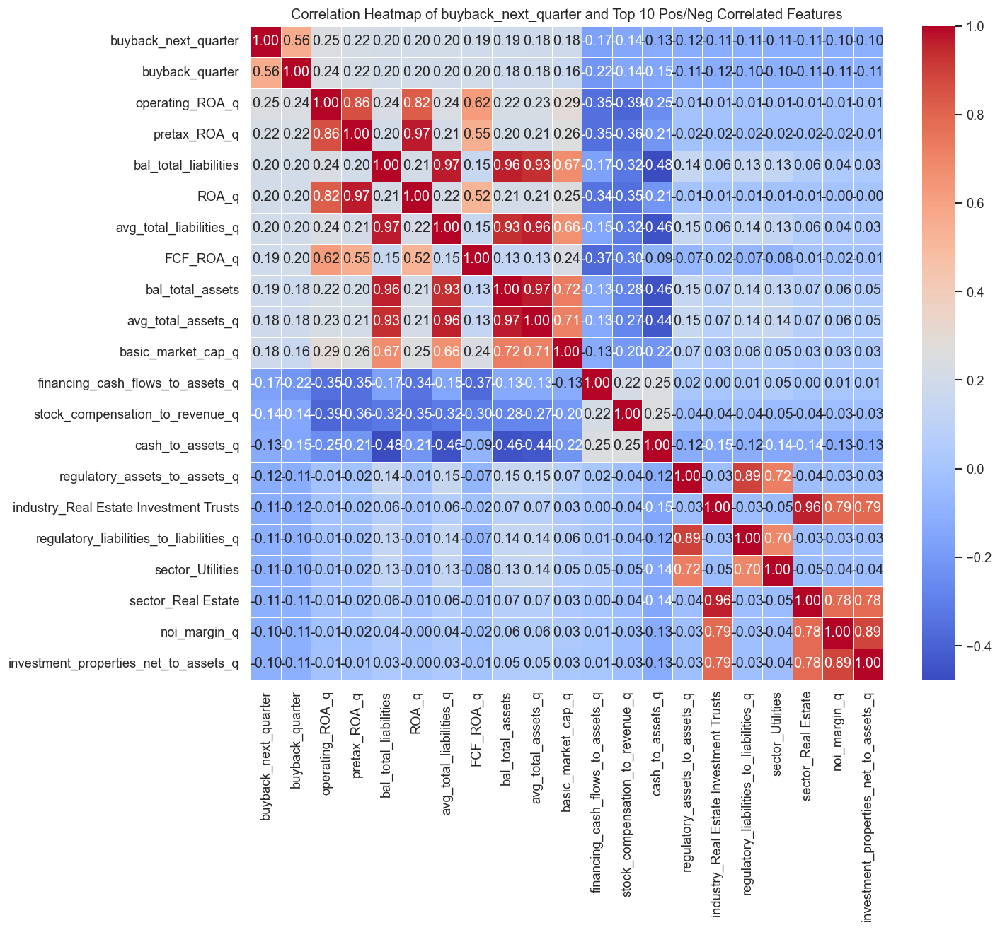

In [14]:
# Drop target itself and any NaN correlations first
buyback_corr_clean = buyback_corr.drop(labels=["buyback_next_quarter"], errors="ignore").dropna()

# Get top positive features
top_positive_features = buyback_corr_clean.sort_values(ascending=False).head(10).index.tolist()

# Get top negative features
top_negative_features = buyback_corr_clean.sort_values(ascending=True).head(10).index.tolist()

# Combine for heatmap
selected_features_for_heatmap = ["buyback_next_quarter"] + top_positive_features + top_negative_features

train_for_corr = X_train_imputed_encoded.copy()
train_for_corr["buyback_next_quarter"] = y_train.values

# Remove duplicates just in case
selected_features_for_heatmap = list(dict.fromkeys(selected_features_for_heatmap))

# Subset dataframe
train_subset_for_heatmap = train_for_corr[selected_features_for_heatmap]

# Correlation matrix for subset
correlation_subset = train_subset_for_heatmap.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_subset, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of buyback_next_quarter and Top 10 Pos/Neg Correlated Features")
plt.show()

## LASSO Logistic Regression

In [15]:
# Identify dummy columns that should not be scaled
dummy_cols = [c for c in X_train_imputed_encoded.columns if c.startswith("sector_") or c.startswith("fiscal_month_")]

# Also do not scale buyback_quarter
no_scale_cols = dummy_cols + ([ "buyback_quarter" ] if "buyback_quarter" in X_train_imputed_encoded.columns else [])

# Scale everything else
scale_cols = [c for c in X_train_imputed_encoded.columns if c not in no_scale_cols]

# Create basic lasso logistic regression model
basic_lasso_logit = Pipeline([
    ("preprocessor", ColumnTransformer(
        [("scale", StandardScaler(), scale_cols)],
        remainder="passthrough"
    )),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=1,
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

# Fit basic model
basic_lasso_logit.fit(X_train_imputed_encoded, y_train)

# Evaluate basic model
res_basic_lasso = evaluate_model("Basic Lasso Logistic Regression", basic_lasso_logit, X_train_imputed_encoded, y_train, X_val_imputed_encoded, y_val)

  Basic Lasso Logistic Regression
  Accuracy:    0.7864
  AUC-ROC:     0.8392
  Sensitivity: 0.7273  (correctly identified buybacks)
  Specificity: 0.8302  (correctly identified non-buybacks)
  F-1 Score:   0.7434

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1652           338
  Actual 1:       402          1072



## KNN

In [16]:
k = 3 # usually don't pick even numbers for k in classification problems to avoid ties 

# Dummy columns we do NOT want to scale
dummy_cols = [c for c in X_train_imputed_encoded.columns if c.startswith("sector_") or c.startswith("fiscal_month_")]

# Also do not scale buyback_quarter
no_scale_cols = dummy_cols + (["buyback_quarter"] if "buyback_quarter" in X_train_imputed_encoded.columns else [])

basic_KNN = Pipeline([
    ("preprocessor", ColumnTransformer(
        [("scale", StandardScaler(), [c for c in X_train_imputed_encoded.columns if c not in no_scale_cols])],
        remainder="passthrough"
    )),
    ("knn", KNeighborsClassifier(n_neighbors=k))
])

evaluate_model("Basic KNN", basic_KNN, X_train_imputed_encoded, y_train, X_val_imputed_encoded, y_val, scaled=False)

  Basic KNN
  Accuracy:    0.7439
  AUC-ROC:     0.7961
  Sensitivity: 0.7062  (correctly identified buybacks)
  Specificity: 0.7719  (correctly identified non-buybacks)
  F-1 Score:   0.7012

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1536           454
  Actual 1:       433          1041



{'name': 'Basic KNN',
 'model': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('scale', StandardScaler(),
                                                   ['fiscal_year', 'inc_revenue',
                                                    'inc_cost_of_revenue',
                                                    'inc_gross_profit',
                                                    'inc_operating_expenses',
                                                    'inc_selling_general_administrative',
                                                    'inc_depreciation_amortization',
                                                    'inc_stock_based_compensation',
                                                    'inc_operating_income',
                                                    'inc_interest_expe...
                                                    'inc_comprehensive_income',


## Tree

In [17]:
# Dummy variables for sector and Q column:

categorical_cols = X_train_shared.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

X_train_shared_CART = pd.get_dummies(X_train_shared, columns=categorical_cols, drop_first=False)
X_val_shared_CART = pd.get_dummies(X_val_shared, columns=categorical_cols, drop_first=False)
X_test_shared_CART = pd.get_dummies(X_test_shared, columns=categorical_cols, drop_first=False)

# Make val/test have same columns as train
X_val_shared_CART = X_val_shared_CART.reindex(columns=X_train_shared_CART.columns, fill_value=0)
X_test_shared_CART = X_test_shared_CART.reindex(columns=X_train_shared_CART.columns, fill_value=0)

basic_CART = Pipeline([
    ("cart", DecisionTreeClassifier(
        criterion='gini',
        min_samples_split=2,
        random_state=RANDOM_STATE
    ))
])

evaluate_model("Basic Tree", basic_CART, X_train_shared_CART, y_train, X_val_shared_CART, y_val, scaled=False)


Categorical columns to encode: ['fiscal_period', 'fiscal_month', 'inc_currency', 'bal_currency', 'cf_currency', 'sector', 'industry']
  Basic Tree
  Accuracy:    0.7053
  AUC-ROC:     0.6990
  Sensitivity: 0.6567  (correctly identified buybacks)
  Specificity: 0.7412  (correctly identified non-buybacks)
  F-1 Score:   0.6547

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1475           515
  Actual 1:       506           968



{'name': 'Basic Tree',
 'model': Pipeline(steps=[('cart', DecisionTreeClassifier(random_state=51))]),
 'auc': 0.6989612240306007,
 'accuracy': np.float64(0.7052540415704388),
 'sensitivity': np.float64(0.6567164179104478),
 'specificity': np.float64(0.7412060301507538),
 'f1_score': 0.6547176192086575}

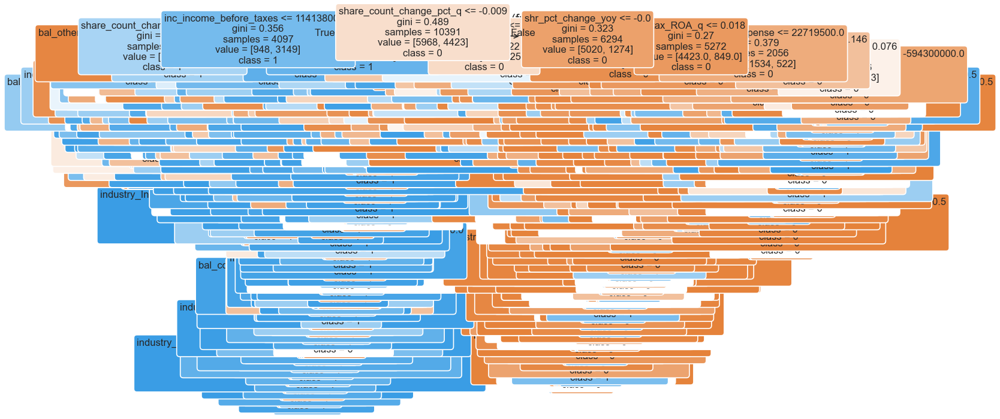

In [18]:
tree_model = basic_CART.named_steps["cart"]

column_names_for_CART = X_train_shared_CART.columns.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(
    tree_model,
    feature_names=column_names_for_CART,
    class_names=[str(x) for x in tree_model.classes_],   # ChatGPT helped me with this line
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title("Buyback Classification Tree (full — no depth limit)", fontsize=13)
plt.tight_layout()
plt.show()

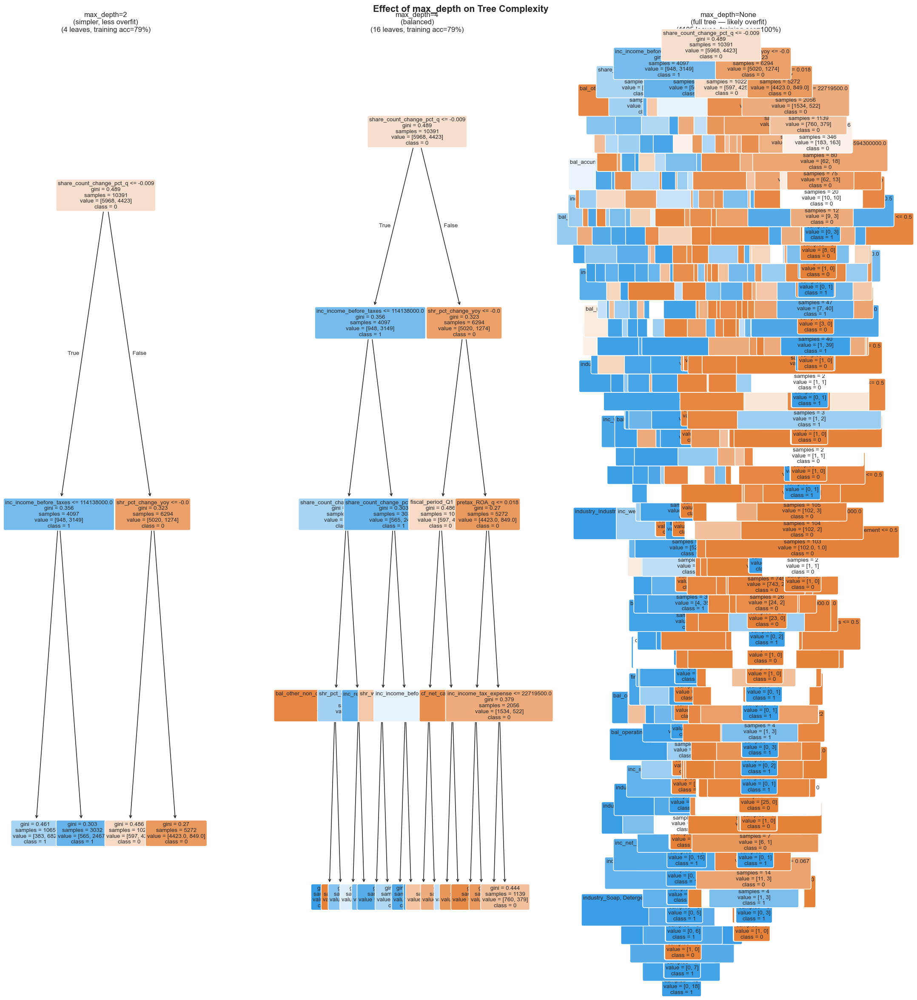


💡 Notice: more leaves = higher training accuracy, but that doesn't mean it generalizes!


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 20))

for ax, depth, title in zip(
    axes,
    [2, 4, None],
    ['max_depth=2\n(simpler, less overfit)', 'max_depth=4\n(balanced)', 'max_depth=None\n(full tree — likely overfit)']
):
    clf = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        random_state=RANDOM_STATE)
    
    clf.fit(X_train_shared_CART, y_train)
    
    plot_tree(
        clf,
        feature_names=X_train_shared_CART.columns.tolist(),
        class_names=[str(x) for x in clf.classes_],   # ChatGPT helped me with this line
        filled=True,
        rounded=True,
        fontsize=8,
        ax=ax)
    
    leaves = sum(1 for i in range(clf.tree_.node_count) if clf.tree_.children_left[i] == -1)
    
    ax.set_title(
        f'{title}\n({leaves} leaves, training acc={clf.score(X_train_shared_CART, y_train):.0%})',
        fontsize=10)

plt.suptitle('Effect of max_depth on Tree Complexity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Notice: more leaves = higher training accuracy, but that doesn't mean it generalizes!")

# Random Forest

In [20]:
random_forest = Pipeline([
    ("rf", RandomForestClassifier(
        n_estimators=500,
        max_features=4,
        min_samples_leaf=5,
        max_leaf_nodes=30,
        oob_score=True,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

res_rf = evaluate_model("Random Forest", random_forest, X_train_shared_CART, y_train, X_val_shared_CART, y_val)

print(f"OOB Score (≈ cross-validated accuracy): {random_forest.named_steps['rf'].oob_score_:.4f}")
print(f"Number of features: {random_forest.named_steps['rf'].n_features_in_}")

  Random Forest
  Accuracy:    0.7512
  AUC-ROC:     0.8161
  Sensitivity: 0.6493  (correctly identified buybacks)
  Specificity: 0.8266  (correctly identified non-buybacks)
  F-1 Score:   0.6895

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1645           345
  Actual 1:       517           957

OOB Score (≈ cross-validated accuracy): 0.7489
Number of features: 654


# XGBoost

In [21]:
# Take the original shared dataset and dummy code the categorical/object variables

# Dummy variables for sector and Q column:
categorical_cols = X_train_shared.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

X_train_shared_XGBoost = pd.get_dummies(X_train_shared, columns=categorical_cols, drop_first=False)
X_val_shared_XGBoost = pd.get_dummies(X_val_shared, columns=categorical_cols, drop_first=False)
X_test_shared_XGBoost = pd.get_dummies(X_test_shared, columns=categorical_cols, drop_first=False)

# Make val/test have same columns as train
X_val_shared_XGBoost = X_val_shared.reindex(columns=X_train_shared_CART.columns, fill_value=0)
X_test_shared_XGBoost = X_test_shared.reindex(columns=X_train_shared_CART.columns, fill_value=0)

Categorical columns to encode: ['fiscal_period', 'fiscal_month', 'inc_currency', 'bal_currency', 'cf_currency', 'sector', 'industry']


In [22]:
XGBoost = Pipeline([
    ("xgb_clf", xgb.XGBClassifier(
        n_estimators=10000,       # set high — early stopping will find the right number
        learning_rate=0.05,
        max_depth=3,
        gamma=0,
        colsample_bytree=0.8,
        min_child_weight=1,
        subsample=0.8,
        reg_alpha=0.1,           # L1 regularization
        reg_lambda=1.0,          # L2 regularization (default)
        eval_metric='auc',       # metric to monitor during early stopping
        use_label_encoder=False,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

# Due to environment-specific issues, direct early stopping arguments are not working.
# The model will train for the full n_estimators=5000 rounds.
res_xgb = evaluate_model("XGBoost", XGBoost, X_train_shared_XGBoost, y_train, X_val_shared_XGBoost, y_val,
    xgb_clf__eval_set=[ # After each boosting roubnd, calculate auc on these datasets and save the history... ChatGPT assisted
        (X_train_shared_XGBoost, y_train),
        (X_val_shared_XGBoost, y_val)
    ]
)

# These attributes are not available without early stopping.
# print(f"Best number of trees (early stopping): {xgb_clf.best_iteration}")
# print(f"Best validation AUC during training:   {xgb_clf.best_score:.4f}")
print("XGBoost model trained without explicit early stopping due to environment constraints.")

[0]	validation_0-auc:0.83658	validation_1-auc:0.82592
[1]	validation_0-auc:0.84163	validation_1-auc:0.83033
[2]	validation_0-auc:0.84264	validation_1-auc:0.83022
[3]	validation_0-auc:0.84978	validation_1-auc:0.83660
[4]	validation_0-auc:0.85117	validation_1-auc:0.83768
[5]	validation_0-auc:0.85229	validation_1-auc:0.83964
[6]	validation_0-auc:0.85365	validation_1-auc:0.84025
[7]	validation_0-auc:0.85530	validation_1-auc:0.84115
[8]	validation_0-auc:0.85678	validation_1-auc:0.84289
[9]	validation_0-auc:0.85709	validation_1-auc:0.84313
[10]	validation_0-auc:0.85810	validation_1-auc:0.84452
[11]	validation_0-auc:0.85851	validation_1-auc:0.84467
[12]	validation_0-auc:0.85895	validation_1-auc:0.84485
[13]	validation_0-auc:0.85897	validation_1-auc:0.84460
[14]	validation_0-auc:0.85953	validation_1-auc:0.84498
[15]	validation_0-auc:0.85999	validation_1-auc:0.84528
[16]	validation_0-auc:0.86053	validation_1-auc:0.84583
[17]	validation_0-auc:0.86113	validation_1-auc:0.84654
[18]	validation_0-au

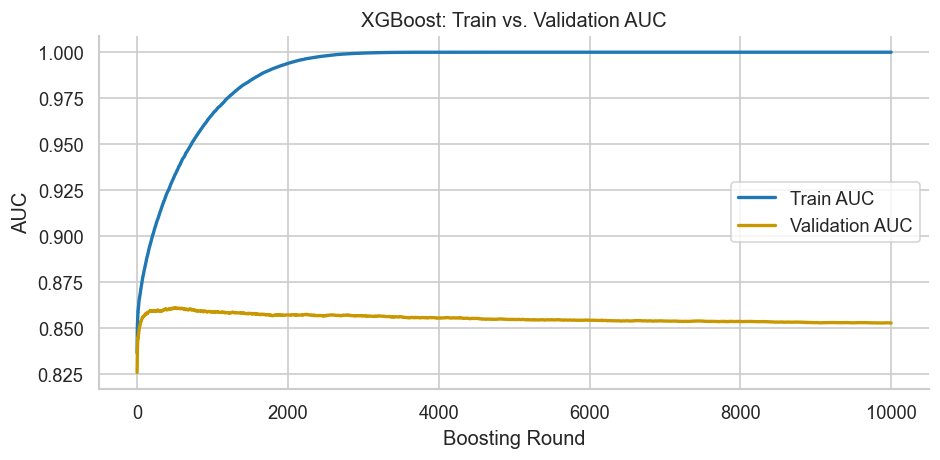

In [23]:
# ── 5.3 XGBoost Learning Curve ────────────────────────────────────────────────
# Visualize train vs. validation AUC at each boosting round
# This shows EXACTLY when overfitting starts

results = XGBoost.named_steps["xgb_clf"].evals_result()
rounds = range(len(results['validation_0']['auc']))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rounds, results['validation_0']['auc'], label='Train AUC', color='#1f77b4', linewidth=2)
ax.plot(rounds, results['validation_1']['auc'], label='Validation AUC', color='#C99700', linewidth=2)
# Removed ax.axvline(xgb_clf.best_iteration, ...) because best_iteration is not available without early stopping.
ax.set_xlabel('Boosting Round')
ax.set_ylabel('AUC')
ax.set_title('XGBoost: Train vs. Validation AUC')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Let's compare Models now

<table border="1">
  <tr>
    <td>Model</td>
    <td>Accuracy</td>
    <td>AUC-ROC</td>
    <td>F-1 Score</td>

  </tr>
  <tr>
    <td>Basic Logistic Regression</td>
    <td>0.7775</td>
    <td>0.8327</td>
    <td>0.7261</td>
  </tr>
  <tr>
    <td>Basic LASSO Regression</td>
    <td>0.7778</td>
    <td>0.8335</td>
    <td>0.7267</td>
  </tr>
  <tr>
    <td>Basic KNN</td>
    <td>0.7266</td>
    <td>0.7743</td>
    <td>0.6731</td>
  </tr>
  <tr>
    <td>Basic Tree</td>
    <td>0.7106</td>
    <td>0.7034</td>
    <td>0.6552</td>
  </tr>
  <tr>
    <td>Random Forest</td>
    <td>0.7423</td>
    <td>0.8141</td>
    <td>0.6483</td>
  </tr>
  <tr>
    <td>XGBoost</td>
    <td>0.7837</td>
    <td>0.8561</td>
    <td>0.7376</td>   
  </tr>
</table>

# Tuning Logistic Regression

In [24]:
# Cross Validation

cv_logit_model = LogisticRegression()

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Perform cross-validation with all features
cv_scores2 = cross_val_score(
    cv_logit_model, X_train_imputed_encoded, y_train,
    cv=cv_strategy, scoring='roc_auc'
)

print("\nCross-Validation Results (All features):")
print(f"Accuracy scores for each fold: {cv_scores2}")
print(f"Mean accuracy: {cv_scores2.mean():.4f}")
print(f"Standard deviation: {cv_scores2.std():.4f}")

# Train the model on full training data
cv_logit_model.fit(X_train_imputed_encoded, y_train)

print(f"Full model (All features): {cv_scores2.mean():.4f} ± {cv_scores2.std():.4f}")


Cross-Validation Results (All features):
Accuracy scores for each fold: [0.68453094 0.69526365 0.69287899 0.68620626 0.71517752]
Mean accuracy: 0.6948
Standard deviation: 0.0109
Full model (All features): 0.6948 ± 0.0109


In [25]:
# Create logistic regression model
cv_logit_model = LogisticRegression(max_iter=1000)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Define parameters to tune
param_grid = {
        'solver': ['liblinear'],
        'penalty': ['l1'],
        'C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10],
        'class_weight': [None, 'balanced']    
}

# Perform cross-validation with all features
grid_search = GridSearchCV(
    cv_logit_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose = 4 # Looked up how to see progress, was taking forever
)

grid_search.fit(X_train_imputed_encoded, y_train)

print("\nCross-Validation Results (All features):")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation AUC: {grid_search.best_score_:.4f}")

# Train and evaluate the best tuned model on validation data
best_logit_model = grid_search.best_estimator_

evaluate_model("Tuned Logistic Regression", best_logit_model, X_train_imputed_encoded, y_train, X_val_imputed_encoded, y_val)


Fitting 5 folds for each of 14 candidates, totalling 70 fits

Cross-Validation Results (All features):
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation AUC: 0.8409
  Tuned Logistic Regression
  Accuracy:    0.7849
  AUC-ROC:     0.8424
  Sensitivity: 0.7598  (correctly identified buybacks)
  Specificity: 0.8035  (correctly identified non-buybacks)
  F-1 Score:   0.7504

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1599           391
  Actual 1:       354          1120



{'name': 'Tuned Logistic Regression',
 'model': LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                    solver='liblinear'),
 'auc': 0.8423624226969311,
 'accuracy': np.float64(0.7849307159353349),
 'sensitivity': np.float64(0.7598371777476255),
 'specificity': np.float64(0.8035175879396985),
 'f1_score': 0.7504187604690117}

In [26]:
# We will now play around with probability threshold tuning:

# Function to evaluation function at custom threshold (ChatGPT helped me a bit with this function, especially scikitlearn notation)
def evaluate_model_at_threshold(name, model, X_ev, y_ev, threshold=0.5):
    """
    Predict using a custom probability threshold and print a clean evaluation summary.
    """
    probs = model.predict_proba(X_ev)[:, 1] 
    preds = (probs >= threshold).astype(int)

    cm = confusion_matrix(y_ev, preds)
    auc = roc_auc_score(y_ev, probs)
    acc = (preds == y_ev).mean()
    f1 = f1_score(y_ev, preds)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)   # recall for positive class
    specificity = tn / (tn + fp)

    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Threshold:   {threshold:.2f}")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  AUC-ROC:     {auc:.4f}")
    print(f"  Sensitivity: {sensitivity:.4f}  (correctly identified buybacks)")
    print(f"  Specificity: {specificity:.4f}  (correctly identified non-buybacks)")
    print(f"  F-1 Score:   {f1:.4f}")
    print()
    print("  Confusion Matrix:")
    print("             Predicted 0   Predicted 1")
    print(f"  Actual 0:      {tn:4d}          {fp:4d}")
    print(f"  Actual 1:      {fn:4d}          {tp:4d}")

    return {
        "Model": name,
        "Threshold": threshold,
        "Accuracy": acc,
        "AUC": auc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1": f1,
        "Confusion Matrix": cm
    }

In [27]:
# ── Logistic Regression Threshold Tuning ──────────────────────────────────────
# Default predict() uses a 0.50 cutoff, but here we search for the threshold that gives the best validation accuracy

val_probs = best_logit_model.predict_proba(X_val_imputed_encoded)[:, 1]

threshold_results = []

for t in np.arange(0.30, 0.71, 0.01):
    preds = (val_probs >= t).astype(int)
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    threshold_results.append({
        "threshold": round(t, 2),
        "accuracy": acc,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

best_row = threshold_df.loc[threshold_df["accuracy"].idxmax()]
best_threshold_logit = best_row["threshold"]

print(f"\nBest validation threshold: {best_threshold_logit:.2f}")
print(f"Best validation accuracy:  {best_row['accuracy']:.4f}")
print(f"Validation F1 at best threshold: {best_row['f1']:.4f}")


# ── Tuned Logistic Regression Validation Results at Best Threshold ────────────
val_preds_best_thresh = (val_probs >= best_threshold_logit).astype(int)

cm = confusion_matrix(y_val, val_preds_best_thresh)
auc = roc_auc_score(y_val, val_probs)
acc = accuracy_score(y_val, val_preds_best_thresh)
f1 = f1_score(y_val, val_preds_best_thresh)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)   # recall for positive class
specificity = tn / (tn + fp)

print(f"{'='*50}")
print(f"  Tuned Logistic Regression (Best Threshold)")
print(f"{'='*50}")
print(f"  Threshold:   {best_threshold_logit:.4f}")
print(f"  Accuracy:    {acc:.4f}")
print(f"  AUC-ROC:     {auc:.4f}")
print(f"  Sensitivity: {sensitivity:.4f}  (correctly identified buybacks)")
print(f"  Specificity: {specificity:.4f}  (correctly identified non-buybacks)")
print(f"  F-1 Score:   {f1:.4f}")
print()
print("  Confusion Matrix:")
print("             Predicted 0   Predicted 1")
print(f"  Actual 0:      {tn:4d}          {fp:4d}")
print(f"  Actual 1:      {fn:4d}          {tp:4d}")


Best validation threshold: 0.55
Best validation accuracy:  0.7872
Validation F1 at best threshold: 0.7459
  Tuned Logistic Regression (Best Threshold)
  Threshold:   0.5500
  Accuracy:    0.7872
  AUC-ROC:     0.8424
  Sensitivity: 0.7341  (correctly identified buybacks)
  Specificity: 0.8266  (correctly identified non-buybacks)
  F-1 Score:   0.7459

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1645           345
  Actual 1:       392          1082


## Tuning LASSO Logistic Regression

In [28]:
# Create cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Define parameters to tune
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
}

# Perform cross-validation
lasso_logit_cv = GridSearchCV(
    estimator=Pipeline([
        ("preprocessor", ColumnTransformer(
            [("scale", StandardScaler(), scale_cols)],
            remainder="passthrough"
        )),
        ("model", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

# Fit grid search
lasso_logit_cv.fit(X_train_imputed_encoded, y_train)

print("Best parameters:", lasso_logit_cv.best_params_)
print("Best CV ROC-AUC:", lasso_logit_cv.best_score_)

# Save best model
best_lasso_logit = lasso_logit_cv.best_estimator_

# Determine best threshold
val_probs = best_lasso_logit.predict_proba(X_val_imputed_encoded)[:, 1]

threshold_results = []

for t in np.arange(0.30, 0.71, 0.01):
    preds = (val_probs >= t).astype(int)
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    threshold_results.append({
        "threshold": round(t, 2),
        "accuracy": acc,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

best_row = threshold_df.loc[threshold_df["accuracy"].idxmax()]
best_threshold_lasso = best_row["threshold"]

print(f"\nBest validation threshold: {best_threshold_lasso:.2f}")
print(f"Best validation accuracy:  {best_row['accuracy']:.4f}")
print(f"Validation F1 at best threshold: {best_row['f1']:.4f}")

# Evaluate tuned model
val_preds_best_thresh = (val_probs >= best_threshold_lasso).astype(int)

cm = confusion_matrix(y_val, val_preds_best_thresh)
auc = roc_auc_score(y_val, val_probs)
acc = accuracy_score(y_val, val_preds_best_thresh)
f1 = f1_score(y_val, val_preds_best_thresh)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)   # recall for positive class
specificity = tn / (tn + fp)

print(f"{'='*50}")
print(f"  Tuned Lasso Logistic Regression (Best Threshold)")
print(f"{'='*50}")
print(f"  Threshold:   {best_threshold_lasso:.4f}")
print(f"  Accuracy:    {acc:.4f}")
print(f"  AUC-ROC:     {auc:.4f}")
print(f"  Sensitivity: {sensitivity:.4f}  (correctly identified buybacks)")
print(f"  Specificity: {specificity:.4f}  (correctly identified non-buybacks)")
print(f"  F-1 Score:   {f1:.4f}")
print()
print("  Confusion Matrix:")
print("             Predicted 0   Predicted 1")
print(f"  Actual 0:      {tn:4d}          {fp:4d}")
print(f"  Actual 1:      {fn:4d}          {tp:4d}")

res_lasso = {
    "name": "Tuned Lasso Logistic Regression (Best Threshold)",
    "model": best_lasso_logit,
    "auc": auc,
    "accuracy": acc,
    "sensitivity": sensitivity,
    "specificity": specificity,
    "f1_score": f1,
    "threshold": best_threshold_lasso
}

Best parameters: {'model__C': 0.1, 'model__class_weight': 'balanced'}
Best CV ROC-AUC: 0.8410412593288988

Best validation threshold: 0.59
Best validation accuracy:  0.7878
Validation F1 at best threshold: 0.7424
  Tuned Lasso Logistic Regression (Best Threshold)
  Threshold:   0.5900
  Accuracy:    0.7878
  AUC-ROC:     0.8433
  Sensitivity: 0.7185  (correctly identified buybacks)
  Specificity: 0.8392  (correctly identified non-buybacks)
  F-1 Score:   0.7424

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1670           320
  Actual 1:       415          1059


In [29]:
# Determine which features are selected:

best_lasso = lasso_logit_cv.best_estimator_

feature_names = best_lasso.named_steps["preprocessor"].get_feature_names_out()
coefs = best_lasso.named_steps["model"].coef_[0]

lasso_results = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

selected_features = lasso_results[lasso_results["coefficient"] != 0].copy()

# To see whole dataset
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(selected_features.sort_values("coefficient", ascending=False))

                                               feature  coefficient
627                         remainder__buyback_quarter     1.961250
96                              scale__operating_ROA_q     0.401865
36                        scale__bal_total_liabilities     0.260147
73                           scale__basic_market_cap_q     0.167400
1                                   scale__inc_revenue     0.139445
61                      scale__cf_capital_expenditures     0.136042
364                            scale__fiscal_period_Q1     0.134316
632                    remainder__fiscal_month_January     0.115288
242                           scale__dac_to_premiums_q     0.104395
371  scale__industry_Abrasive, Asbestos & Misc Nonm...     0.095206
132                             scale__FCF_per_share_q     0.087602
370                             scale__cf_currency_USD     0.087026
494                 scale__industry_Operative Builders     0.085851
253           scale__acquisition_cost_deferral_r

# Tuning XGBoost

In [30]:
# ── 5.5 XGBoost Hyperparameter Tuning ────────────────────────────────────────
param_grid_xgb = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 6],
    'learning_rate':     [0.01, 0.05, 0.1],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.7, 0.8],
    'reg_alpha':         [0, 0.1],
}

grid_xgb = GridSearchCV(
    xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=4 # Gives me status
)

grid_xgb.fit(X_train_shared_XGBoost, y_train)

print(f"Best XGBoost params: {grid_xgb.best_params_}")
print(f"Best CV AUC:         {grid_xgb.best_score_:.4f}")

xgb_best = grid_xgb.best_estimator_
res_xgb_best = evaluate_model("Tuned XGBoost", xgb_best, X_train_shared_XGBoost, y_train, X_val_shared_XGBoost, y_val)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'reg_alpha': 0, 'subsample': 0.8}
Best CV AUC:         0.8689
  Tuned XGBoost
  Accuracy:    0.7959
  AUC-ROC:     0.8639
  Sensitivity: 0.7517  (correctly identified buybacks)
  Specificity: 0.8286  (correctly identified non-buybacks)
  F-1 Score:   0.7581

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1649           341
  Actual 1:       366          1108



In [31]:
# XGBoost Threshold Tuning:
#   Default predict() uses a 0.50 cutoff, but here we search for the threshold that gives the best validation accuracy

val_probs = xgb_best.predict_proba(X_val_shared_XGBoost)[:, 1]

threshold_results = []

for t in np.arange(0.30, 0.71, 0.01):
    preds = (val_probs >= t).astype(int)
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    threshold_results.append({
        "threshold": round(t, 2),
        "accuracy": acc,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

best_row = threshold_df.loc[threshold_df["accuracy"].idxmax()] #idmaxc suggested by ChatGPT
best_threshold_xgb = best_row["threshold"]

print(f"Best validation threshold: {best_threshold_xgb:.2f}")
print(f"Best validation accuracy:  {best_row['accuracy']:.4f}")
print(f"Validation F1 at best threshold: {best_row['f1']:.4f}")

Best validation threshold: 0.46
Best validation accuracy:  0.7965
Validation F1 at best threshold: 0.7633


In [32]:
# Tuned XGBoost validation results at best threshold
res_xgb_best_thresh = evaluate_model_at_threshold("Tuned XGBoost (Best Threshold)", xgb_best, X_val_shared_XGBoost, y_val, threshold=best_threshold_xgb)

  Tuned XGBoost (Best Threshold)
  Threshold:   0.46
  Accuracy:    0.7965
  AUC-ROC:     0.8639
  Sensitivity: 0.7714  (correctly identified buybacks)
  Specificity: 0.8151  (correctly identified non-buybacks)
  F-1 Score:   0.7633

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1622           368
  Actual 1:       337          1137


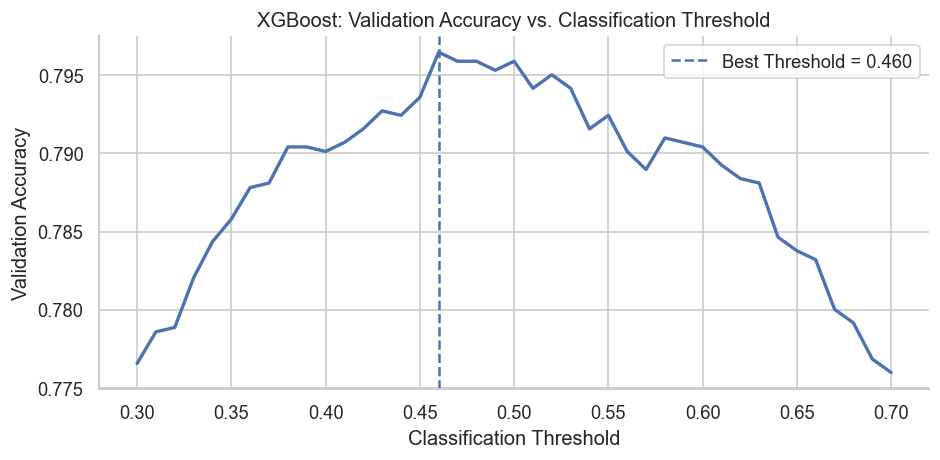

In [33]:
# Plot Threshold vs. Validation accuracy (ChatGPT suggested this based on scikitlearn user guide webpage: 3.3 tuning the decision threshold for class prediction)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(threshold_df["threshold"], threshold_df["accuracy"], linewidth=2)
ax.axvline(best_threshold_xgb, linestyle='--', linewidth=1.5, label=f'Best Threshold = {best_threshold_xgb:.3f}')

ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Validation Accuracy")
ax.set_title("XGBoost: Validation Accuracy vs. Classification Threshold")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Let's compare Best Chosen Tuned Models:

<table>
  <tr>
    <td>Model</td>
    <td>Threshold</td>
    <td>Accuracy</td>
    <td>AUC-ROC</td>
    <td>F-1 Score</td>

  </tr>
  <tr>
    <td>Tuned Logistic Regression (Best Threshold)</td>
    <td>0.5200</td>
    <td>0.7805</td>
    <td>0.8361</td>
    <td>0.7270</td>
  </tr>
  <tr>
    <td>Tuned LASSO Logistic Regression (Best Threshold)</td>
    <td>0.5200</td>
    <td>0.7794</td>
    <td>0.8343</td>
    <td>0.7258</td>
  </tr>  
  <tr>
    <td>Tuned XGBoost (Best Threshold)</td>
    <td>0.5200</td>
    <td>0.7949</td>
    <td>0.8634</td>
    <td>0.7468</td>

  </tr>
</table>

## Winner:

In [34]:
# automatically finds threshold with best accuracy
best_threshold_xgb = threshold_df.loc[threshold_df["accuracy"].idxmax(), "threshold"] # I consulted ChatGPT for this line, got confused

# Freeze the model so we can save it for later
best_model = xgb.XGBClassifier(
    colsample_bytree=grid_xgb.best_params_["colsample_bytree"],
    learning_rate=grid_xgb.best_params_["learning_rate"],
    max_depth=grid_xgb.best_params_["max_depth"],
    n_estimators=grid_xgb.best_params_["n_estimators"],
    reg_alpha=grid_xgb.best_params_["reg_alpha"],
    subsample=grid_xgb.best_params_["subsample"],
    random_state=RANDOM_STATE
)

# Fit on training data
best_model.fit(X_train_shared_XGBoost, y_train)

# Evaluate on validation data
evaluate_model_at_threshold("Best Model", best_model, X_val_shared_XGBoost, y_val, threshold=best_threshold_xgb)

  Best Model
  Threshold:   0.46
  Accuracy:    0.7965
  AUC-ROC:     0.8639
  Sensitivity: 0.7714  (correctly identified buybacks)
  Specificity: 0.8151  (correctly identified non-buybacks)
  F-1 Score:   0.7633

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1622           368
  Actual 1:       337          1137


{'Model': 'Best Model',
 'Threshold': np.float64(0.46),
 'Accuracy': np.float64(0.7964780600461894),
 'AUC': 0.8638586419205935,
 'Sensitivity': np.float64(0.771370420624152),
 'Specificity': np.float64(0.8150753768844221),
 'F1': 0.7633434038267876,
 'Confusion Matrix': array([[1622,  368],
        [ 337, 1137]])}

In [35]:
# Run the final test evaluation once!

results_best_model = evaluate_model_at_threshold("Best Model (Test)", best_model, X_test_shared_XGBoost, y_test, threshold=best_threshold_xgb)

# There is an indication of overfitting since the val accuracy > test accuracy => not severely overfit (it's okay)

  Best Model (Test)
  Threshold:   0.46
  Accuracy:    0.7893
  AUC-ROC:     0.8678
  Sensitivity: 0.7397  (correctly identified buybacks)
  Specificity: 0.8260  (correctly identified non-buybacks)
  F-1 Score:   0.7493

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1643           346
  Actual 1:       384          1091


In [36]:
# Predict on the test subset

test_probs = best_model.predict_proba(X_test_shared_XGBoost)[:, 1]
test_preds = (test_probs >= best_threshold_xgb).astype(int)
display(test_preds)

array([1, 0, 0, ..., 0, 1, 1], shape=(3464,))

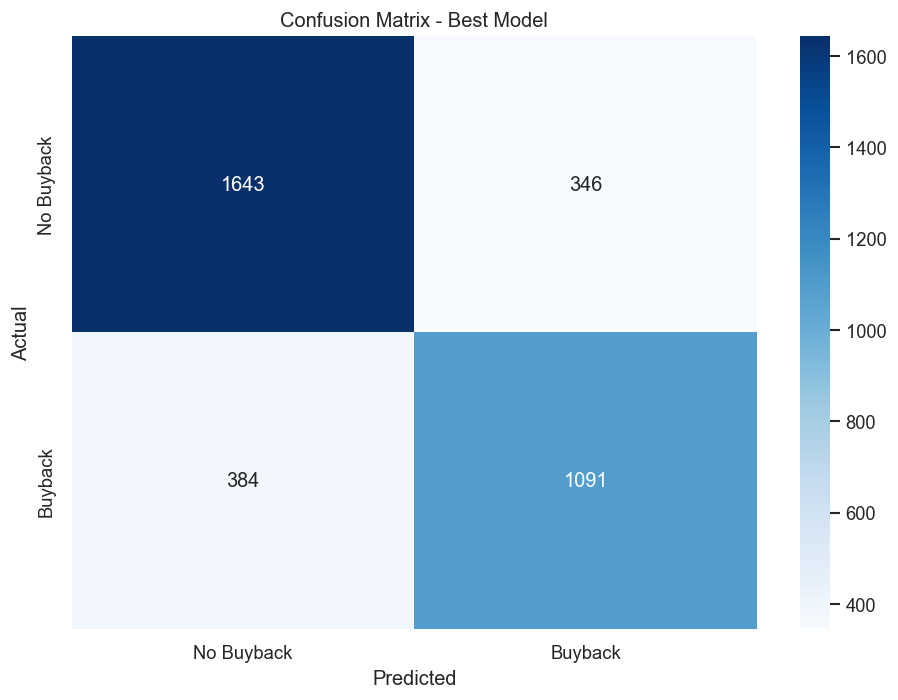

In [37]:
# Confusion Matrix

cm_final = confusion_matrix(y_test, test_preds)

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Buyback', 'Buyback'],
            yticklabels=['No Buyback', 'Buyback'])
plt.title('Confusion Matrix - Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

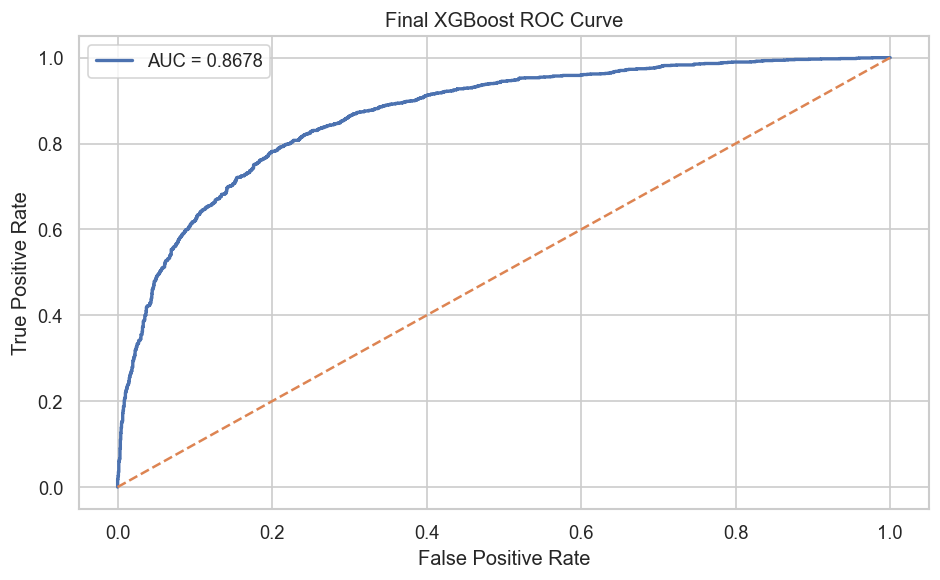

In [38]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
auc = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final XGBoost ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

,Feature,Importance
72,buyback_quarter,0.147457
130,share_count_change_pct_q,0.048681
151,shr_pct_change_yoy,0.009634
365,fiscal_period_Q1,0.008511
98,pretax_ROA_q,0.008109
14,inc_net_income,0.007423
11,inc_income_before_taxes,0.006752
323,revenue_per_property_q,0.006135
368,fiscal_period_Q4,0.005995
12,inc_income_tax_expense,0.005964


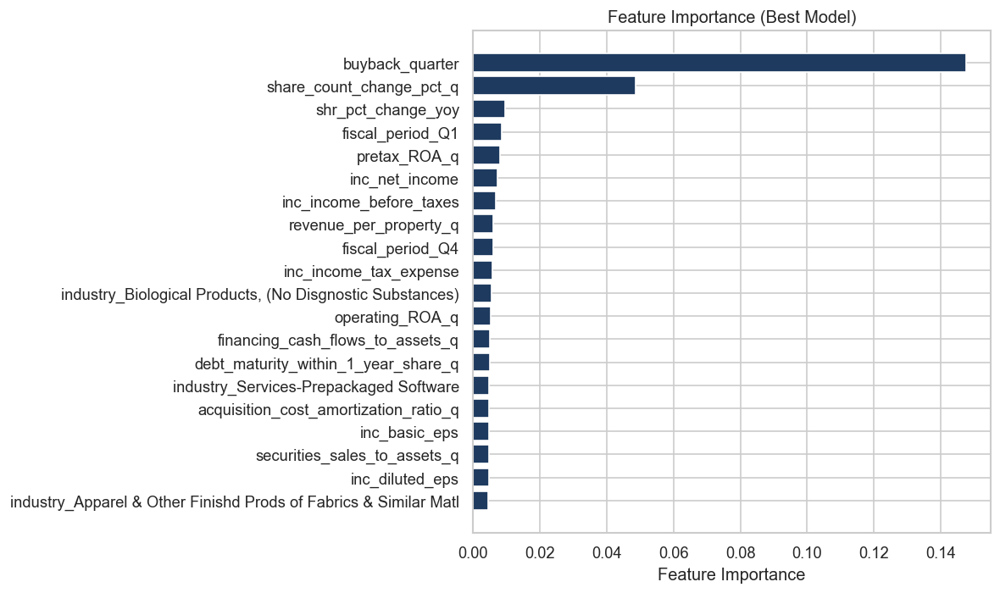

In [39]:
# Feature Importance:

feature_importance = pd.DataFrame({
    "Feature": X_train_shared_XGBoost.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)


# Plot top 20 so it stays readable
top_features = feature_importance.head(20).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"], color="#1E3A5F")
plt.xlabel("Feature Importance")
plt.title("Feature Importance (Best Model)")
plt.tight_layout()
plt.show()

## SHAP

In [40]:
# ── 7.1 Compute SHAP Values ───────────────────────────────────────────────────
# TreeExplainer is optimized for RF, XGBoost, LightGBM — very fast
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_shared_XGBoost)

print(f"SHAP values shape: {shap_values.shape}")
print(f"(rows = validation samples, cols = features)")
print(f"\nFirst row SHAP values: {np.round(shap_values[0], 4)}")
print(f"Feature names: {list(X_test_shared_XGBoost.columns)}")


SHAP values shape: (3464, 654)
(rows = validation samples, cols = features)

First row SHAP values: [-9.5000e-03 -8.7500e-02 -7.8000e-03 -2.1800e-02 -2.3000e-02 -3.4600e-02
 -2.2300e-02  4.9200e-02  6.5000e-03  1.1900e-02  7.1000e-03 -6.2000e-02
 -8.6000e-02 -5.2000e-03 -3.0000e-04  3.1000e-03  5.8000e-03  2.2000e-03
 -2.6800e-02 -6.5800e-02  2.7500e-02  1.9100e-02 -8.1000e-03 -1.8000e-02
  3.1300e-02 -2.6600e-02  5.5000e-03  5.7000e-03  8.6000e-03  1.3100e-02
 -3.8000e-03 -2.2000e-02 -1.7000e-02  2.1100e-02 -9.4000e-03 -2.5000e-03
 -4.6000e-03  9.2000e-03 -3.3300e-02 -9.6000e-03 -1.1000e-02  3.4500e-02
 -1.0400e-02  1.5000e-03  8.0000e-04 -1.7800e-02  4.6000e-03  1.4000e-03
 -3.7500e-02 -7.1000e-03  1.8300e-02  1.9100e-02  1.2000e-02  1.1800e-02
  2.7500e-02 -1.5100e-02 -1.4300e-02 -1.0600e-02 -4.1600e-02 -7.5900e-02
  2.0000e-02  1.5000e-03  5.4600e-02 -3.5000e-03  9.6000e-03 -1.5500e-02
  2.0000e-04 -1.0900e-02  4.1000e-03 -1.9000e-03 -1.9000e-03 -2.8700e-02
  2.0120e-01 -2.3000e-03

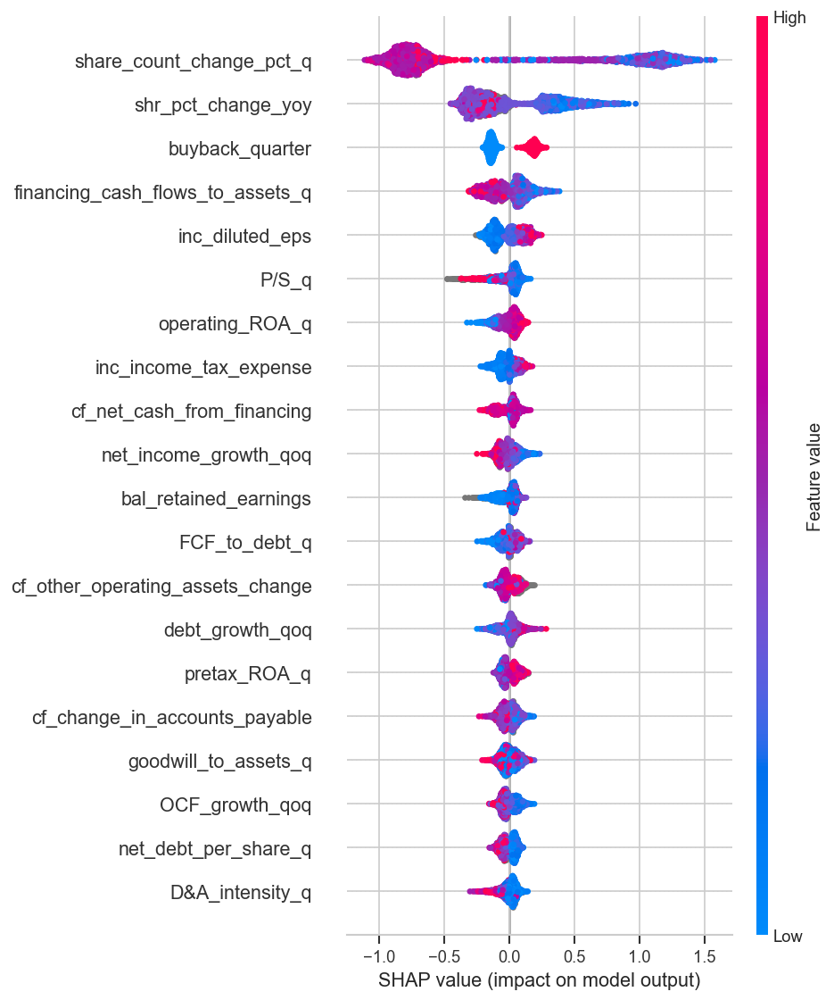

In [41]:
# ── 7.2 Beeswarm Plot — Global Feature Importance ────────────────────────────
# Each dot = one sample. Color = feature value (red=high, blue=low).
# Horizontal position = impact on prediction.
# Most important feature at top.

shap.summary_plot(shap_values, X_test_shared_XGBoost, plot_type='dot', show=True)

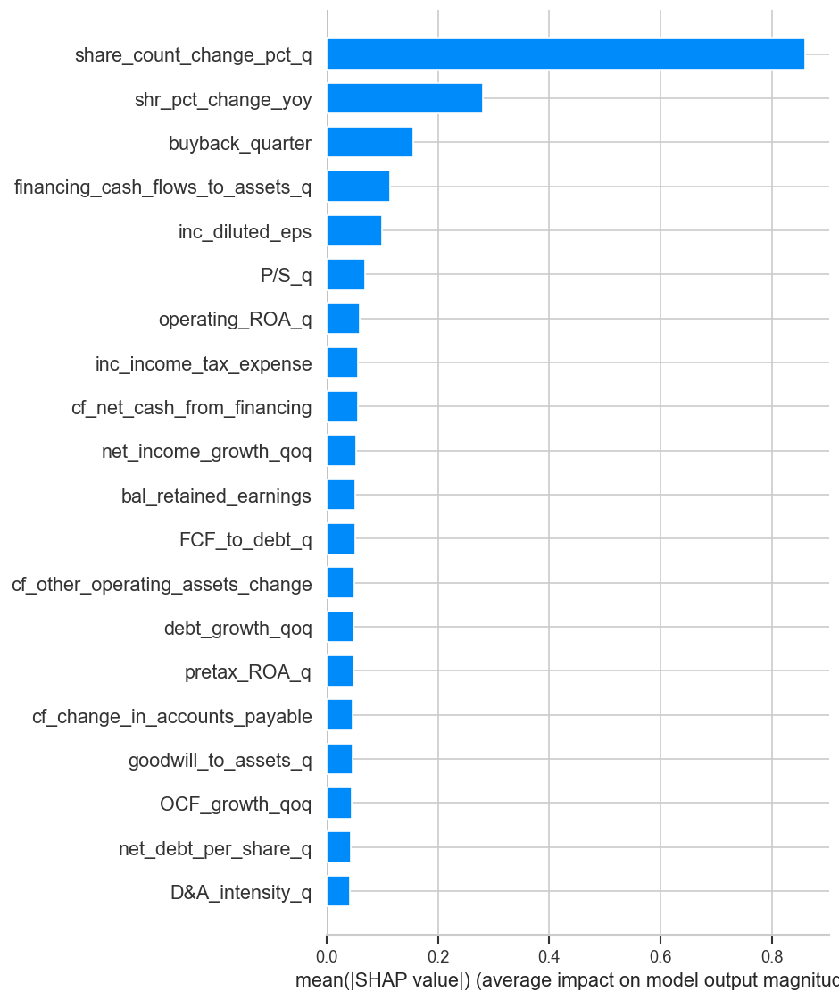

In [42]:
# ── 7.3 Bar Plot — Mean Absolute SHAP Importance ─────────────────────────────
shap.summary_plot(shap_values, X_val_shared_XGBoost, plot_type='bar', show=True)


Explaining prediction for validation record index 1
True label: 1  |  Predicted: 0
Predicted probability: 0.4189

Customer profile:
      fiscal_year  inc_revenue  inc_cost_of_revenue  inc_gross_profit  inc_operating_expenses  inc_selling_general_administrative  inc_depreciation_amortization  inc_stock_based_compensation  inc_operating_income  inc_interest_expense  inc_other_income_expense  inc_income_before_taxes  inc_income_tax_expense  inc_net_income_continuing_operations  inc_net_income  inc_basic_shares_outstanding  inc_weighted_average_basic_shares  inc_weighted_average_diluted_shares  inc_basic_eps  inc_diluted_eps  inc_comprehensive_income  inc_other_comprehensive_income  inc_net_income_available_to_common  inc_income_before_taxes_and_extraordinary  inc_other_comprehensive_income_net_of_tax  inc_comprehensive_income_net_of_tax  bal_total_assets  bal_current_assets  bal_non_current_assets  bal_cash_and_equivalents  bal_accounts_receivable  bal_property_plant_equipment  bal_goodw

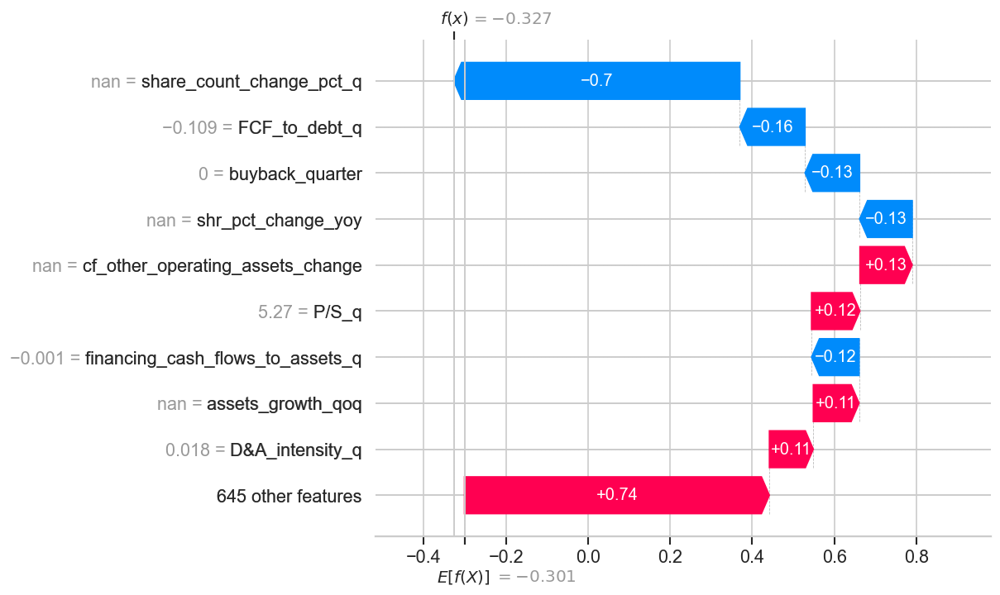

In [43]:
# ── 7.4 Waterfall Plot — Explain ONE Individual Prediction ───────────────────
# Pick an interesting record: a stock which actually got a buyback (y=1)
buyback_idx = np.where(y_test.values == 1)[0][0]  # first actual buyback in val set

print(f"Explaining prediction for validation record index {buyback_idx}")
print(f"True label: {y_test.iloc[buyback_idx]}  |  Predicted: {best_model.predict(X_test_shared_XGBoost)[buyback_idx]}")
print(f"Predicted probability: {best_model.predict_proba(X_test_shared_XGBoost)[buyback_idx, 1]:.4f}")
print(f"\nCustomer profile:")
print(X_test_shared_XGBoost.iloc[[buyback_idx]].to_string())

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[buyback_idx],
        base_values=explainer.expected_value,
        data=X_test_shared_XGBoost.iloc[buyback_idx].values,
        feature_names=X_test_shared_XGBoost.columns.tolist()
    )
)


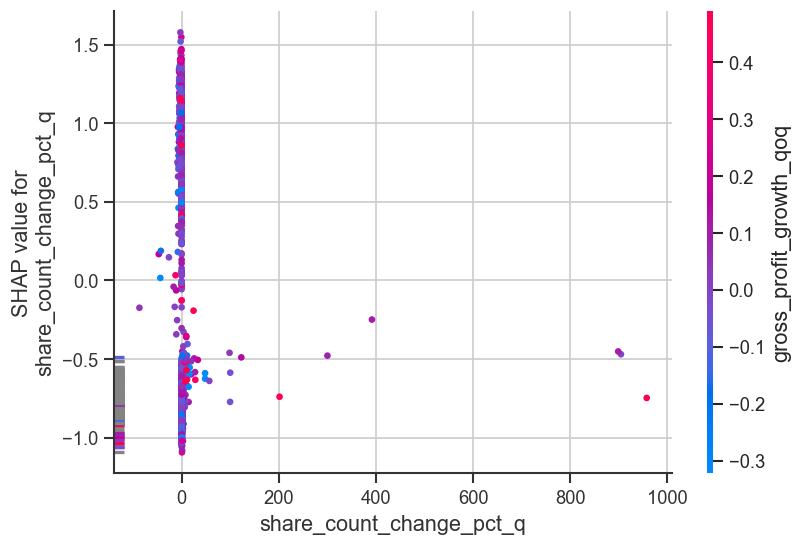

In [44]:
# ── 7.5 Dependence Plot — Income Effect ──────────────────────────────────────
# Shows how Income SHAP value changes across the range of cf_repurchase_of_stock values
# Color = value of the most interacting feature (automatic)

shap.dependence_plot('share_count_change_pct_q', shap_values, X_test_shared_XGBoost, show=True)

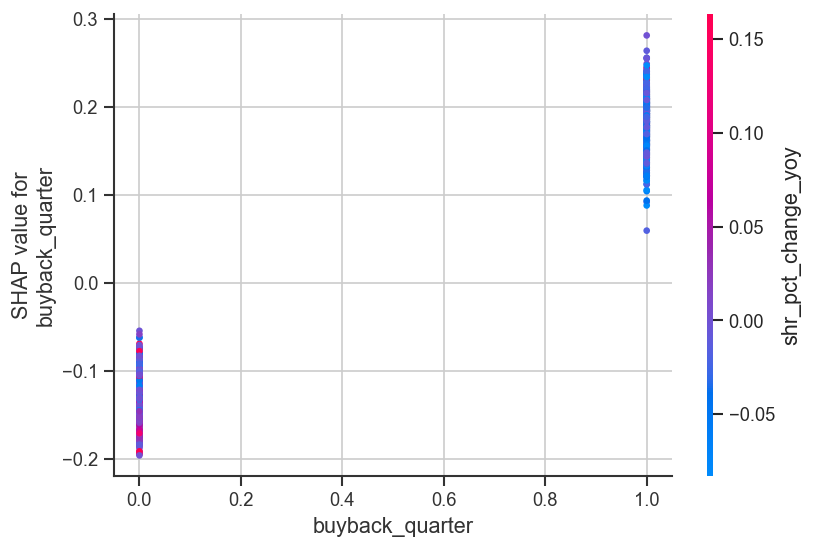

In [45]:
# ── 7.5 Dependence Plot — buyback_quarter Effect ──────────────────────────────────────
# Shows how buyback_quarter SHAP value changes across the range of cf_repurchase_of_stock values
# Color = value of the most interacting feature (automatic)

shap.dependence_plot('buyback_quarter', shap_values, X_test_shared_XGBoost, show=True)

In [46]:
# ── 7.6 Business Interpretation ──────────────────────────────────────────────
# Generate a plain-English summary per top-5 features

top_features = pd.DataFrame({
    'feature': X_test_shared_XGBoost.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).head(5)

print("Top 5 Features by Mean |SHAP| (Global Importance):")
print("=" * 60)
for _, row in top_features.iterrows():
    print(f"  {row['feature']:20s}  mean |SHAP| = {row['mean_abs_shap']:.4f}")


Top 5 Features by Mean |SHAP| (Global Importance):
  share_count_change_pct_q  mean |SHAP| = 0.8596
  shr_pct_change_yoy    mean |SHAP| = 0.2812
  buyback_quarter       mean |SHAP| = 0.1557
  financing_cash_flows_to_assets_q  mean |SHAP| = 0.1148
  inc_diluted_eps       mean |SHAP| = 0.1003


# Baseline Model


In [47]:
X_baseline_imputed_encoded_train = X_train_imputed_encoded.copy()
X_baseline_imputed_encoded_val = X_val_imputed_encoded.copy()
X_baseline_imputed_encoded_test = X_test_imputed_encoded.copy()

X_baseline_imputed_encoded_train = X_baseline_imputed_encoded_train[['buyback_quarter']]
X_baseline_imputed_encoded_val = X_baseline_imputed_encoded_val[['buyback_quarter']]
X_baseline_imputed_encoded_test = X_baseline_imputed_encoded_test[['buyback_quarter']]

# Baseline model using only buyback_quarter
baseline_model = Pipeline([
    ("model", LogisticRegression())
])

evaluate_model("Baseline Model", baseline_model, X_baseline_imputed_encoded_train, y_train, X_baseline_imputed_encoded_val, y_val, scaled=False)

  Baseline Model
  Accuracy:    0.7835
  AUC-ROC:     0.7763
  Sensitivity: 0.7280  (correctly identified buybacks)
  Specificity: 0.8246  (correctly identified non-buybacks)
  F-1 Score:   0.7410

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1641           349
  Actual 1:       401          1073



{'name': 'Baseline Model',
 'model': Pipeline(steps=[('model', LogisticRegression())]),
 'auc': 0.7762871344510884,
 'accuracy': np.float64(0.7834872979214781),
 'sensitivity': np.float64(0.7279511533242876),
 'specificity': np.float64(0.8246231155778895),
 'f1_score': 0.7410220994475138}

# What happens if we remove the most significant variables pertaining to current quarter buyback?

Categorical columns to encode: ['fiscal_period', 'fiscal_month', 'inc_currency', 'bal_currency', 'cf_currency', 'sector', 'industry']
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'reg_alpha': 0.1, 'subsample': 0.7}
Best CV AUC:         0.8576
  Tuned XGBoost
  Accuracy:    0.7771
  AUC-ROC:     0.8539
  Sensitivity: 0.7395  (correctly identified buybacks)
  Specificity: 0.8050  (correctly identified non-buybacks)
  F-1 Score:   0.7385

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1602           388
  Actual 1:       384          1090

Best validation threshold: 0.49
Best validation accuracy:  0.7780
Validation F1 at best threshold: 0.7412
  Tuned XGBoost (Best Threshold)
  Threshold:   0.49
  Accuracy:    0.7780
  AUC-ROC:     0.8539
  Sensitivity: 0.7469  (correctly identified buybacks)
  Specificity: 0.8010  (correctly identified

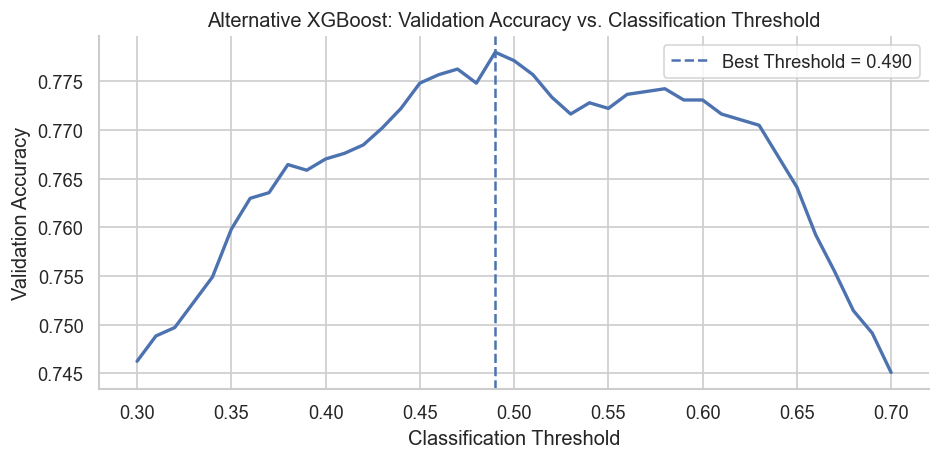

  Best Alternative Model (Test)
  Threshold:   0.49
  Accuracy:    0.7855
  AUC-ROC:     0.8611
  Sensitivity: 0.7505  (correctly identified buybacks)
  Specificity: 0.8115  (correctly identified non-buybacks)
  F-1 Score:   0.7487

  Confusion Matrix:
             Predicted 0   Predicted 1
  Actual 0:      1614           375
  Actual 1:       368          1107


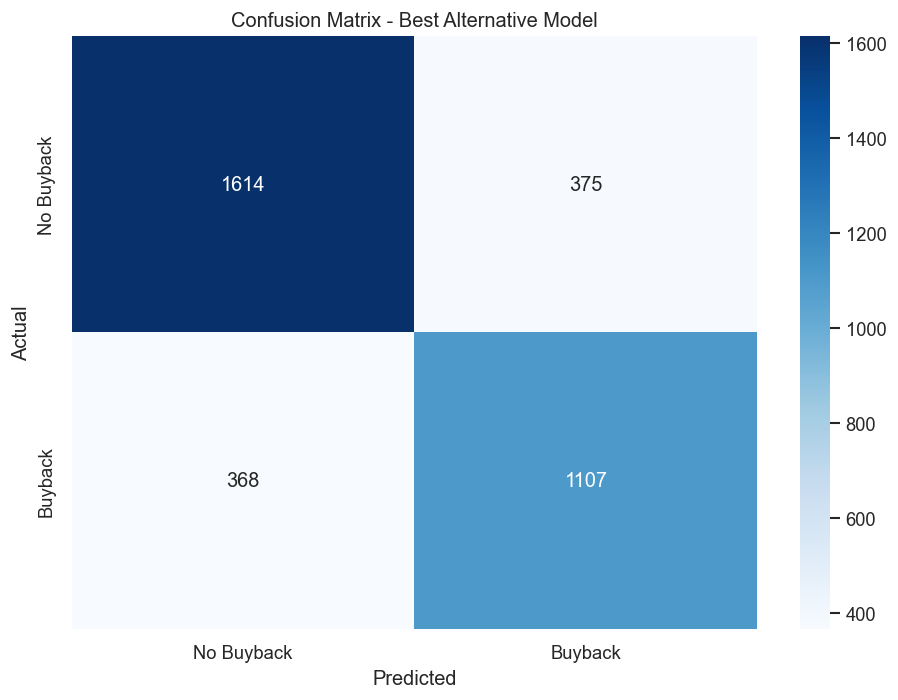

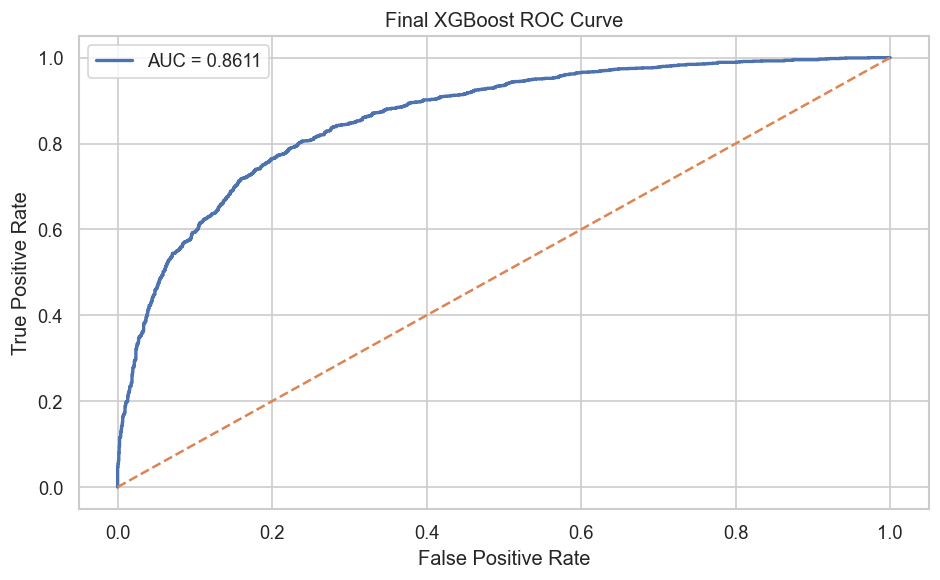

,Feature,Importance
18,inc_basic_eps,0.034827
393,sector_Utilities,0.020731
62,cf_net_cash_from_financing,0.020627
11,inc_income_before_taxes,0.018209
160,regulatory_assets_to_assets_q,0.013021
92,tax_burden_ratio_q,0.011592
514,industry_Newspapers: Publishing or Publishing ...,0.009874
175,cwip_to_assets_utility_q,0.009613
128,financing_cash_flows_to_assets_q,0.009040
582,"industry_Services-Business Services, NEC",0.008262


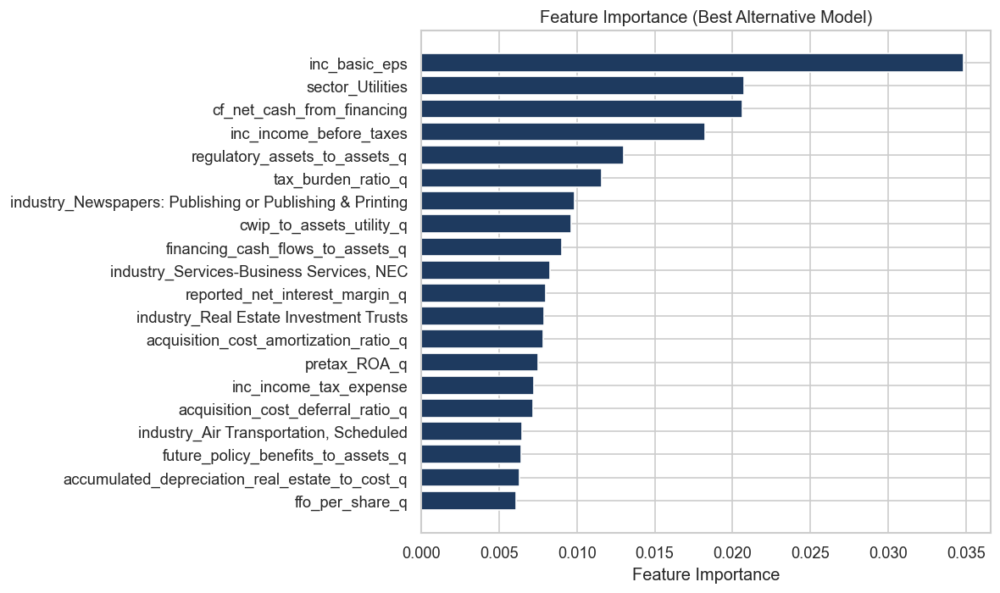

SHAP values shape: (3464, 651)
(rows = test samples, cols = features)

First row SHAP values: [-8.400e-03 -3.390e-02  7.000e-03 -7.100e-03 -3.140e-02 -4.190e-02
 -5.410e-02  5.290e-02  4.400e-03 -1.800e-03  2.500e-02  2.380e-02
 -7.600e-02  1.250e-02 -1.000e-04  3.280e-02  2.000e-03 -1.800e-03
 -1.177e-01 -2.720e-02  1.330e-02  1.920e-02 -1.050e-02 -1.620e-02
  2.360e-02  4.200e-03  7.000e-04 -3.600e-03 -4.000e-04  1.570e-02
  1.600e-03  1.200e-02 -2.700e-02  3.020e-02 -1.340e-02 -1.210e-02
 -4.000e-04 -3.000e-04  5.800e-03 -3.600e-03 -4.200e-02 -3.000e-03
 -8.400e-03  9.500e-03 -3.410e-02 -1.290e-02 -1.210e-02 -1.080e-02
 -7.100e-03  2.280e-02  2.490e-02 -1.400e-03  5.600e-03  3.350e-02
  1.000e-02 -2.290e-02 -8.200e-03  4.300e-03 -2.840e-02 -2.920e-02
  2.410e-02  4.000e-03  1.908e-01 -3.380e-02 -2.380e-02 -1.060e-02
  3.700e-03 -6.000e-04  1.770e-02  1.700e-03  5.000e-03 -1.560e-02
 -1.960e-02  2.180e-02  5.500e-03 -4.000e-03  1.000e-04  1.860e-02
 -7.000e-03  2.500e-03  4.360e-02 -

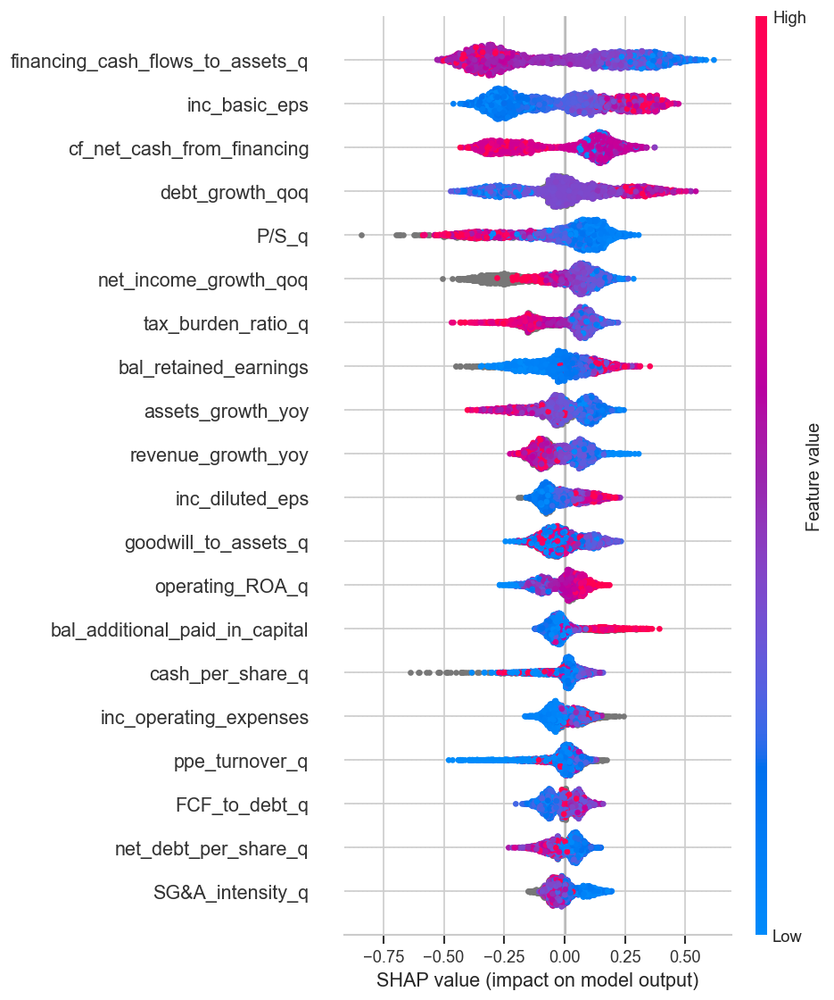

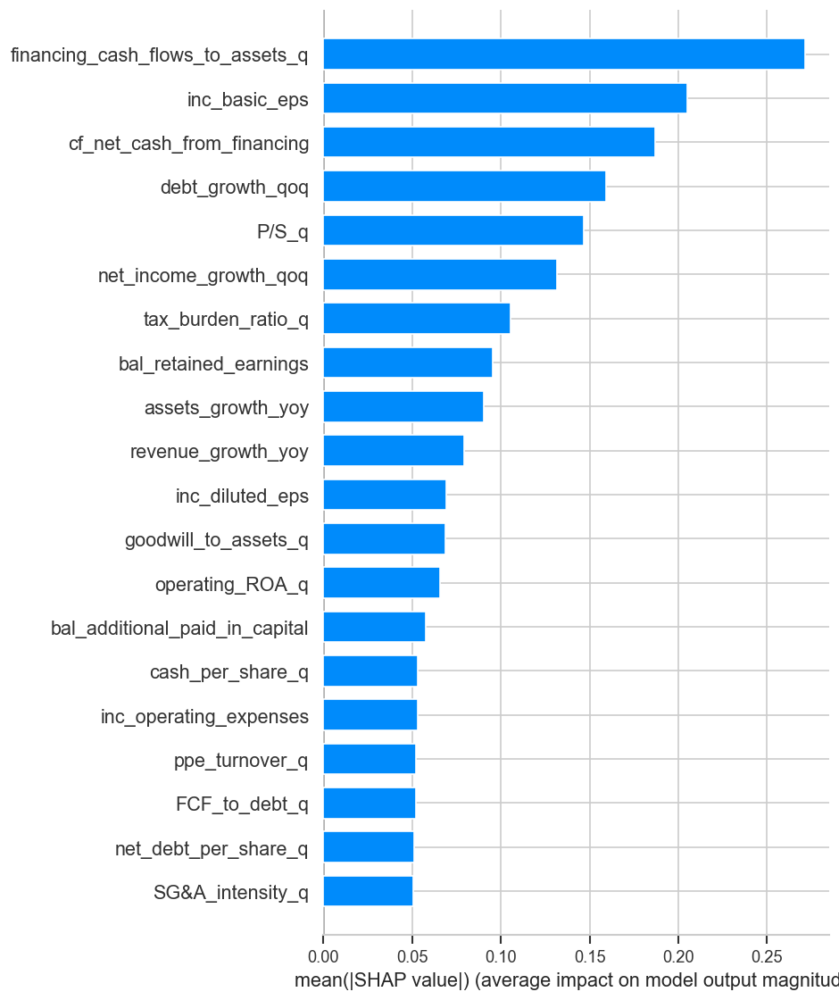

Explaining prediction for test record index 1
True label: 1  |  Predicted: 0
Predicted probability: 0.4869

Stock profile:
      fiscal_year  inc_revenue  inc_cost_of_revenue  inc_gross_profit  inc_operating_expenses  inc_selling_general_administrative  inc_depreciation_amortization  inc_stock_based_compensation  inc_operating_income  inc_interest_expense  inc_other_income_expense  inc_income_before_taxes  inc_income_tax_expense  inc_net_income_continuing_operations  inc_net_income  inc_basic_shares_outstanding  inc_weighted_average_basic_shares  inc_weighted_average_diluted_shares  inc_basic_eps  inc_diluted_eps  inc_comprehensive_income  inc_other_comprehensive_income  inc_net_income_available_to_common  inc_income_before_taxes_and_extraordinary  inc_other_comprehensive_income_net_of_tax  inc_comprehensive_income_net_of_tax  bal_total_assets  bal_current_assets  bal_non_current_assets  bal_cash_and_equivalents  bal_accounts_receivable  bal_property_plant_equipment  bal_goodwill  bal_

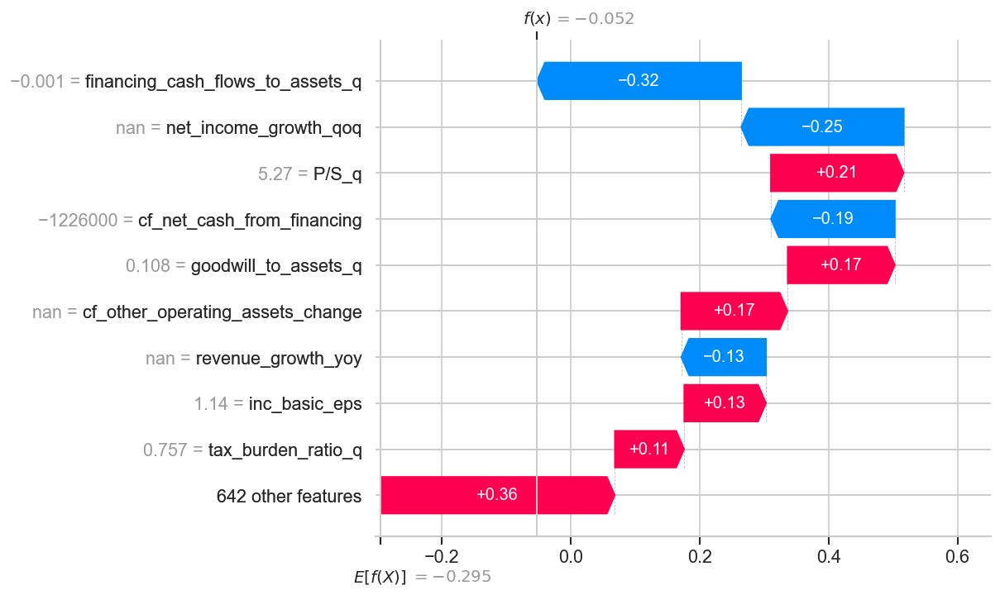

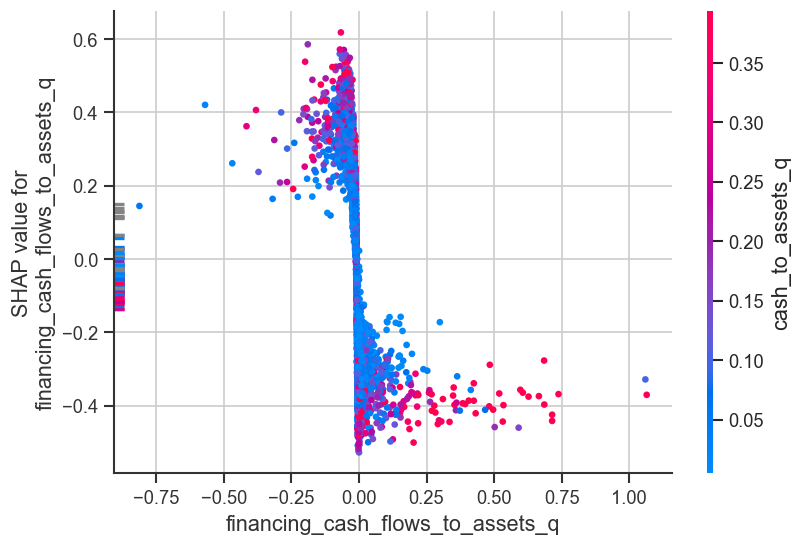

Top 5 Features by Mean |SHAP| (Global Importance):
  financing_cash_flows_to_assets_q  mean |SHAP| = 0.2713
  inc_basic_eps         mean |SHAP| = 0.2051
  cf_net_cash_from_financing  mean |SHAP| = 0.1868
  debt_growth_qoq       mean |SHAP| = 0.1592
  P/S_q                 mean |SHAP| = 0.1468


In [48]:
# XGBoost with non-buyback specific features:


# Take the original shared dataset and dummy code the categorical/object variables

# Dummy variables for sector and Q column:
categorical_cols = X_train_shared.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

X_train_shared_XGBoost = pd.get_dummies(X_train_shared, columns=categorical_cols, drop_first=False)
X_val_shared_XGBoost = pd.get_dummies(X_val_shared, columns=categorical_cols, drop_first=False)
X_test_shared_XGBoost = pd.get_dummies(X_test_shared, columns=categorical_cols, drop_first=False)

# Make val/test have same columns as train
X_val_shared_XGBoost = X_val_shared_XGBoost.reindex(columns=X_train_shared_XGBoost.columns, fill_value=0)
X_test_shared_XGBoost = X_test_shared_XGBoost.reindex(columns=X_train_shared_XGBoost.columns, fill_value=0)

X_train_shared_XGBoost_alternative = X_train_shared_XGBoost.copy()
X_val_shared_XGBoost_alternative = X_val_shared_XGBoost.copy()
X_test_shared_XGBoost_alternative = X_test_shared_XGBoost.copy()

# Drop buyback_quarter and any other buyback-specific features to make it just about fundamentals and valuations
features_to_drop = ['buyback_quarter','shr_shares_change_vs_prior_period','share_growth_yoy','shr_shares_change_percentage',
                    'share_count_change_q','share_count_change_pct_q', 'share_growth_qoq', 'shr_pct_change_yoy']

X_train_shared_XGBoost_alternative = X_train_shared_XGBoost_alternative.drop(columns=features_to_drop, errors='ignore')
X_val_shared_XGBoost_alternative = X_val_shared_XGBoost_alternative.drop(columns=features_to_drop, errors='ignore')
X_test_shared_XGBoost_alternative = X_test_shared_XGBoost_alternative.drop(columns=features_to_drop, errors='ignore')

# ── 5.5 XGBoost Hyperparameter Tuning ────────────────────────────────────────
param_grid_xgb_alternative = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 6],
    'learning_rate':     [0.01, 0.05, 0.1],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.7, 0.8],
    'reg_alpha':         [0, 0.1],
}

grid_xgb_alternative = GridSearchCV(
    xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    param_grid_xgb_alternative,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=4 # Gives me status
)

grid_xgb_alternative.fit(X_train_shared_XGBoost_alternative, y_train)

print(f"Best XGBoost params: {grid_xgb_alternative.best_params_}")
print(f"Best CV AUC:         {grid_xgb_alternative.best_score_:.4f}")

xgb_alternative = grid_xgb_alternative.best_estimator_
evaluate_model("Tuned XGBoost", xgb_alternative, X_train_shared_XGBoost_alternative, y_train, X_val_shared_XGBoost_alternative, y_val)

# XGBoost Threshold Tuning:
#   Default predict() uses a 0.50 cutoff, but here we search for the threshold that gives the best validation accuracy

val_probs = xgb_alternative.predict_proba(X_val_shared_XGBoost_alternative)[:, 1]

threshold_results = []

for t in np.arange(0.30, 0.71, 0.01):
    preds = (val_probs >= t).astype(int)
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    threshold_results.append({
        "threshold": round(t, 2),
        "accuracy": acc,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

best_row = threshold_df.loc[threshold_df["accuracy"].idxmax()] #idmaxc suggested by ChatGPT
best_threshold_xgb_alternative = best_row["threshold"]

print(f"Best validation threshold: {best_threshold_xgb_alternative:.2f}")
print(f"Best validation accuracy:  {best_row['accuracy']:.4f}")
print(f"Validation F1 at best threshold: {best_row['f1']:.4f}")

# Tuned XGBoost validation results at best threshold
evaluate_model_at_threshold("Tuned XGBoost (Best Threshold)", xgb_alternative, X_val_shared_XGBoost_alternative, y_val, threshold=best_threshold_xgb_alternative)

# Plot Threshold vs. Validation accuracy (ChatGPT suggested this based on scikitlearn user guide webpage: 3.3 tuning the decision threshold for class prediction)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(threshold_df["threshold"], threshold_df["accuracy"], linewidth=2)
ax.axvline(best_threshold_xgb_alternative, linestyle='--', linewidth=1.5, label=f'Best Threshold = {best_threshold_xgb_alternative:.3f}')

ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Validation Accuracy")
ax.set_title("Alternative XGBoost: Validation Accuracy vs. Classification Threshold")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Test:

# Run the final test evaluation once!
evaluate_model_at_threshold("Best Alternative Model (Test)", xgb_alternative, X_test_shared_XGBoost_alternative, y_test, threshold=best_threshold_xgb_alternative)

# Predict on the test subset
test_probs = xgb_alternative.predict_proba(X_test_shared_XGBoost_alternative)[:, 1]
test_preds = (test_probs >= best_threshold_xgb_alternative).astype(int)

# Confusion Matrix
cm_final = confusion_matrix(y_test, test_preds)

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Buyback', 'Buyback'],
            yticklabels=['No Buyback', 'Buyback'])
plt.title('Confusion Matrix - Best Alternative Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
auc = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final XGBoost ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance:

feature_importance = pd.DataFrame({
    "Feature": X_train_shared_XGBoost_alternative.columns,
    "Importance": xgb_alternative.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)


# Plot top 20 so it stays readable
top_features = feature_importance.head(20).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"], color="#1E3A5F")
plt.xlabel("Feature Importance")
plt.title("Feature Importance (Best Alternative Model)")
plt.tight_layout()
plt.show()

# ── 7.1 Compute SHAP Values ───────────────────────────────────────────────────
# TreeExplainer is optimized for RF, XGBoost, LightGBM — very fast
explainer = shap.TreeExplainer(xgb_alternative)
shap_values = explainer.shap_values(X_test_shared_XGBoost_alternative)

print(f"SHAP values shape: {shap_values.shape}")
print(f"(rows = test samples, cols = features)")
print(f"\nFirst row SHAP values: {np.round(shap_values[0], 4)}")
print(f"Feature names: {list(X_test_shared_XGBoost_alternative.columns)}")

# ── 7.2 Beeswarm Plot — Global Feature Importance ────────────────────────────
# Each dot = one sample. Color = feature value (red=high, blue=low).
# Horizontal position = impact on prediction.
# Most important feature at top.

shap.summary_plot(shap_values, X_test_shared_XGBoost_alternative, plot_type='dot', show=True)

# ── 7.3 Bar Plot — Mean Absolute SHAP Importance ─────────────────────────────
shap.summary_plot(shap_values, X_test_shared_XGBoost_alternative, plot_type='bar', show=True)

# ── 7.4 Waterfall Plot — Explain ONE Individual Prediction ───────────────────
# Pick an interesting record: a stock which actually got a buyback (y=1)
buyback_idx = np.where(y_test.values == 1)[0][0]  # first actual buyback in test set

print(f"Explaining prediction for test record index {buyback_idx}")
print(f"True label: {y_test.iloc[buyback_idx]}  |  Predicted: {xgb_alternative.predict(X_test_shared_XGBoost_alternative)[buyback_idx]}")
print(f"Predicted probability: {xgb_alternative.predict_proba(X_test_shared_XGBoost_alternative)[buyback_idx, 1]:.4f}")
print(f"\nStock profile:")
print(X_test_shared_XGBoost_alternative.iloc[[buyback_idx]].to_string())

base_value = explainer.expected_value if np.isscalar(explainer.expected_value) else explainer.expected_value[0]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[buyback_idx],
        base_values=base_value,
        data=X_test_shared_XGBoost_alternative.iloc[buyback_idx].values,
        feature_names=X_test_shared_XGBoost_alternative.columns.tolist()
    )
)

# ── 7.5 Dependence Plot — Feature Effect ─────────────────────────────────────
# Shows how SHAP value changes across the range of a chosen feature
# Color = value of the most interacting feature (automatic)

top_feature_name = pd.DataFrame({
    'feature': X_test_shared_XGBoost_alternative.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).iloc[0]['feature']

shap.dependence_plot(top_feature_name, shap_values, X_test_shared_XGBoost_alternative, show=True)

# ── 7.6 Business Interpretation ──────────────────────────────────────────────
# Generate a plain-English summary per top-5 features

top_features = pd.DataFrame({
    'feature': X_test_shared_XGBoost_alternative.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).head(5)

print("Top 5 Features by Mean |SHAP| (Global Importance):")
print("=" * 60)
for _, row in top_features.iterrows():
    print(f"  {row['feature']:20s}  mean |SHAP| = {row['mean_abs_shap']:.4f}")

In [49]:
# Create matching metadata / full rows for train, validation, and test sets
# This assumes the X matrices still have the original df indexes from the split

df_train = df.loc[X_train_shared_XGBoost.index].copy().reset_index(drop=True)
df_val = df.loc[X_val_shared_XGBoost.index].copy().reset_index(drop=True)
df_test = df.loc[X_test_shared_XGBoost.index].copy().reset_index(drop=True)

# Reset X indexes too so rows line up cleanly
X_train_shared_XGBoost = X_train_shared_XGBoost.reset_index(drop=True)
X_val_shared_XGBoost = X_val_shared_XGBoost.reset_index(drop=True)
X_test_shared_XGBoost = X_test_shared_XGBoost.reset_index(drop=True)

X_train_shared_XGBoost_alternative = X_train_shared_XGBoost_alternative.reset_index(drop=True)
X_val_shared_XGBoost_alternative = X_val_shared_XGBoost_alternative.reset_index(drop=True)
X_test_shared_XGBoost_alternative = X_test_shared_XGBoost_alternative.reset_index(drop=True)

# Check that the rows match
print(df_train.shape, X_train_shared_XGBoost.shape, X_train_shared_XGBoost_alternative.shape)
print(df_val.shape, X_val_shared_XGBoost.shape, X_val_shared_XGBoost_alternative.shape)
print(df_test.shape, X_test_shared_XGBoost.shape, X_test_shared_XGBoost_alternative.shape)

(10391, 768) (10391, 654) (10391, 651)
(3464, 768) (3464, 654) (3464, 651)
(3464, 768) (3464, 654) (3464, 651)


In [50]:
# Save information to be used in the "Applying the Models" Jupyter notebook

# Save the main model feature matrices
X_train_shared_XGBoost.to_csv("X_train_shared_XGBoost.csv", index=False)
X_val_shared_XGBoost.to_csv("X_val_shared_XGBoost.csv", index=False)
X_test_shared_XGBoost.to_csv("X_test_shared_XGBoost.csv", index=False)

# Save the alternative model feature matrices
X_train_shared_XGBoost_alternative.to_csv("X_train_shared_XGBoost_alternative.csv", index=False)
X_val_shared_XGBoost_alternative.to_csv("X_val_shared_XGBoost_alternative.csv", index=False)
X_test_shared_XGBoost_alternative.to_csv("X_test_shared_XGBoost_alternative.csv", index=False)

# Save matching metadata / full rows
df_train.to_csv("df_train.csv", index=False)
df_val.to_csv("df_val.csv", index=False)
df_test.to_csv("df_test.csv", index=False)

# Save tickers directly from df
pd.DataFrame({"ticker": sorted(df["ticker"].dropna().unique())}).to_csv(
    "universe_tickers.csv",
    index=False
)

# Save the models
joblib.dump(best_model, "best_model.joblib")
joblib.dump(xgb_alternative, "xgb_alternative.joblib")

print("Files saved successfully.")

Files saved successfully.
